<a href="https://colab.research.google.com/github/jaysulk/Poisson-GENERIC-Neural-Operators/blob/main/ICLR2027_poisson_generic_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Poisson-GENERIC neural operators — experiment notebook

Follow-up to **GENERIC-FNO** (Sulskis & Ravi, 2026).

## 1. Setup and configuration

In [ ]:
import math, time, itertools, copy
from dataclasses import dataclass, asdict, field
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cuda.matmul.allow_tf32 = False   # keep the structural residuals honest
torch.backends.cudnn.allow_tf32 = False
print('device:', DEV, '| torch', torch.__version__)

def seed_all(s):
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def sdims(dim):            # spatial dims of a (B, C, *grid) tensor
    return tuple(range(-dim, 0))

def ip(a, b):              # grid-measure inner product: sum over channels and space / number of grid points -> (B,)
    # NOTE: dividing by the number of grid points only (not channels) keeps the measure independent of the channel
    # count, so Q(u) on the p observed channels and E(z) on the p+1 channels of z use the SAME inner product.  With a
    # per-channel mean, the Riesz-scaled gradient of Q came out (p+1)/p x too large (3x for the wave), the exact
    # exponential integrated only 1/(p+1) of the linear flow and the learned symbols settled at 1/2 (scalar) and 1/3 (wave).
    return (a * b).flatten(1).sum(1) / a[0, 0].numel()

def ip_pointwise(a, b):    # inner product over the channel axis only -> (B, *grid)
    return (a * b).sum(1)

def nrm(a):
    return ip(a, a).sqrt()

def neg_index(a, dim):     # a[..., k] -> a[..., (-k) mod n] on the last `dim` axes (fftn layout)
    d = sdims(dim)
    return torch.roll(torch.flip(a, d), shifts=(1,) * dim, dims=d)

device: cuda | torch 2.11.0+cu128


In [ ]:
@dataclass
class Cfg:
    # problem
    dim: int = 1
    pde: str = 'heat'            # heat | advection | burgers | wave
    nx: int = 64
    n_traj: int = 120
    T: int = 20                  # saved frames per trajectory (beyond t=0)
    dt: float = 0.1              # frame spacing
    kmax: int = 8                # band limit of the initial conditions
    # model
    model: str = 'pg'            # 'pg' (Poisson-GENERIC) | 'base' (unconstrained residual operator)
    backbone: str = 'fno'        # fno | transolver | cno
    width: int = 32              # backbone width (baseline) / functional width (pg)
    modes: int = 12              # FNO modes
    layers: int = 3
    norm: bool = False           # InstanceNorm inside FNO/CNO blocks (paper: needed in 2D, harmful in 1D)
    m_L: int = 16                # band of the Poisson multiplier  (|k|_inf <= m_L, k != 0)
    m_M: int = 16                # band of the dissipative multiplier
    K_mode: str = 'complement'   # kernel band the entropy sees: 'complement' (k=0 and |k|>m_L) | 'mean' (k=0 only)
    s_init: str = 'encoder'      # latent entropy density init: 'encoder' | 'zero'
    op_init: float = 0.1         # init scale of the multiplier symbols (too small -> model starts in the identity basin)
    energy: str = 'learned'      # 'learned': E = h(mean g(u,s)) | 'physical': E = Q(u) + mean e(s), Q fixed, e >= 0 learned
    entropy: str = 'learned'     # 'learned': Casimir functional of (Pi_K u, s) | 'integral': S = mean(s) (exact Casimir)
    m_type: str = 'constant'     # 'constant': D_M multiplier | 'state': A(z)A(z)^T with A = D_M o Gamma(z), Gamma a pointwise matrix field
    n_sub: int = 1               # split integrator: sub-steps for the explicit dissipative remainder (stability: coef*k_max^2/n_sub < 2)
    flux_init: bool = True       # state-M: initialize D_M as gradient/divergence flux slots (model starts as a nonlinear diffusion)
    flux_scale: float = 0.05     # scale of that init; explicit Euler on the dissipative part is stable only if coef*k_max^2 < 2
    lie_poisson: bool = False    # scalar fields: add lambda*(u D + D u), D = sum_a d_a, to L (Lie-Poisson, Poisson; compatible with D):
                                 #   nonlinear transport (Burgers = -(1/3)(uD+Du) delta/du 1/2||u||^2) with a QUADRATIC energy
    phi_gauge: str = 'proj'    # 'taylor': subtract phi's degree-2 Taylor polynomial at 0 (removes the quadratic gauge) | 'none': phi >= 0
    conserve_mass: str = 'auto'  # 'auto': for the scalar conservation laws (heat/advection/burgers) M gets no local (zeroth-order) slot on u,
                                 #   so int u is conserved and there is no Rayleigh-type damping of a conserved density | 'yes' | 'no'
    # training
    epochs: int = 40
    batch: int = 16
    horizon: int = 4             # training rollout horizon
    lr: float = 1e-3
    lr_op: float = 3e-2          # learning rate of the operator symbols a(k), B(k): the true advection symbol is a(k) = -c k dt
                                 #   (= -0.8 at k=8), unreachable from a 0.1 init in ~100 Adam steps at lr 1e-3
    wd: float = 1e-4
    # evaluation
    n_roll: int = 10
    integrator: str = 'euler'    # evaluation integrator: 'euler' | 'dg' (discrete gradient, exact E/S) | 'split' (exact unitary step
                                 #   for the linear reversible part exp(L Hess Q) + Euler for the rest; physical variant only)
    train_integrator: str = 'euler'   # training integrator ('dg' is exact but ~dg_iters x slower)
    dg_iters: int = 6
    seed: int = 0

PDE_PARAMS = {
    'heat':      dict(nu=0.05),
    'advection': dict(c=1.0),
    'burgers':   dict(nu=0.02),
    'wave':      dict(c=1.0, gamma=0.3),
}
def n_fields(pde):           # observed channels p
    return 2 if pde == 'wave' else 1

## 2. Data
Spectral RK4 solver on the periodic box $[0,2\pi)^d$, band-limited random initial conditions (unit RMS). Frame spacing `dt = 0.1` is chosen so that persistence is *far* from the truth over the evaluation horizon — this addresses the near-persistence caveat of the first paper's ten-step tables. Damped wave is fully observed as `(q, v)` (the GENERIC-FNO partial-observation failure is deliberately not reproduced; set the observed channels yourself if you want it).

In [ ]:
class Spectral:
    """Spectral derivatives on the periodic box [0, 2pi)^d with integer wavenumbers."""
    def __init__(self, nx, dim, device=DEV, dtype=torch.float64):
        k = torch.fft.fftfreq(nx, d=1.0 / nx, device=device, dtype=dtype)
        self.ks = torch.meshgrid(*([k] * dim), indexing='ij')
        self.k2 = sum(kk ** 2 for kk in self.ks)
        kinf = torch.stack([kk.abs() for kk in self.ks]).amax(0)
        self.dealias_mask = (kinf < nx / 3.0)          # 2/3 rule
        self.dim = dim; self.d = sdims(dim)
    def fft(self, u):  return torch.fft.fftn(u, dim=self.d)
    def ifft(self, uh): return torch.fft.ifftn(uh, dim=self.d).real
    def deriv(self, u, axis):
        return self.ifft(1j * self.ks[axis] * self.fft(u))
    def lap(self, u):
        return self.ifft(-self.k2 * self.fft(u))
    def dealias(self, u):
        return self.ifft(self.dealias_mask * self.fft(u))

def pde_rhs(pde, u, sp, prm):
    """u: (B, p, *grid) float64. Returns du/dt."""
    if pde == 'heat':
        return prm['nu'] * sp.lap(u)
    if pde == 'advection':
        return -prm['c'] * sum(sp.deriv(u, a) for a in range(sp.dim))
    if pde == 'burgers':
        adv = sum(sp.deriv(u, a) for a in range(sp.dim))
        return -sp.dealias(u * adv) + prm['nu'] * sp.lap(u)
    if pde == 'wave':
        q, v = u[:, :1], u[:, 1:]
        return torch.cat([v, prm['c'] ** 2 * sp.lap(q) - prm['gamma'] * v], 1)
    raise ValueError(pde)

def rk4(f, u, dt):
    k1 = f(u); k2 = f(u + 0.5 * dt * k1); k3 = f(u + 0.5 * dt * k2); k4 = f(u + dt * k3)
    return u + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def random_field(n, nx, dim, kmax, device=DEV, dtype=torch.float64):
    """Band-limited random field with a mild red spectrum, unit RMS."""
    sp = Spectral(nx, dim, device, dtype)
    w = torch.randn(n, 1, *([nx] * dim), device=device, dtype=dtype)
    kinf = torch.stack([kk.abs() for kk in sp.ks]).amax(0)
    mask = (kinf <= kmax) & (kinf > 0)
    amp = 1.0 / (1.0 + sp.k2) ** 0.75
    u = sp.ifft(sp.fft(w) * mask * amp)
    return u / u.flatten(1).std(1).view(n, *([1] * (dim + 1)))

def n_substeps(cfg, nx):
    """RK4 sub-steps per frame from the linear stability limit at this resolution (nu k^2 dt, c k dt < ~2.8)."""
    prm = PDE_PARAMS[cfg.pde]; kmax = nx / 2
    if cfg.pde in ('heat', 'burgers'):
        dt_max = min(0.02, 2.0 / (prm['nu'] * cfg.dim * kmax ** 2))
    else:
        dt_max = min(0.02, 2.0 / (prm['c'] * cfg.dim * kmax))
    return max(1, int(math.ceil(cfg.dt / dt_max)))

def gen_data(cfg, device=DEV):
    """Returns (n_traj, T+1, p, *grid) float32 trajectories."""
    seed_all(cfg.seed)
    p = n_fields(cfg.pde); prm = PDE_PARAMS[cfg.pde]
    sp = Spectral(cfg.nx, cfg.dim, device)
    u = random_field(cfg.n_traj, cfg.nx, cfg.dim, cfg.kmax, device)
    if cfg.pde == 'wave':
        v = 0.5 * random_field(cfg.n_traj, cfg.nx, cfg.dim, cfg.kmax, device)
        u = torch.cat([u, v], 1)
    n_sub = n_substeps(cfg, cfg.nx); dt_sub = cfg.dt / n_sub
    f = lambda x: pde_rhs(cfg.pde, x, sp, prm)
    frames = [u]
    with torch.no_grad():
        for _ in range(cfg.T):
            for _ in range(n_sub):
                u = rk4(f, u, dt_sub)
            frames.append(u)
    return torch.stack(frames, 1).float()

def split_data(data, frac=0.8):
    n = int(frac * data.shape[0])
    return data[:n], data[n:]

## 3. Backbones
Three dimension-generic backbones with one interface `(B, C_in, *grid) → (B, C_out, *grid)`:
* **FNO** (Li et al., 2021) with optional InstanceNorm per block (the normalization the first paper diagnosed as necessary in 2D / harmful in 1D — `cfg.norm`);
* **Transolver** physics-attention (Wu et al., ICML 2024): grid points → learned slices → attention among slices → back. Dimension-agnostic on flattened tokens;
* **CNO-lite**: periodic convolutional U-shape in the spirit of CNO (Raonic et al., 2023), without the alias-free activation machinery.

All three serve both as the unconstrained baseline `u_{t+1} = u_t + G(u_t)` and as the backbone of the learned functionals `E_θ, S_φ` and the entropy encoder.

In [ ]:
def ConvNd(dim):  return {1: nn.Conv1d, 2: nn.Conv2d}[dim]
def INormNd(dim): return {1: nn.InstanceNorm1d, 2: nn.InstanceNorm2d}[dim]

def coord_grid(x):
    """(B, C, *grid) -> (B, dim, *grid) coordinates in [0,1)."""
    B, dim = x.shape[0], x.dim() - 2
    axes = [torch.linspace(0, 1, x.shape[2 + i] + 1, device=x.device, dtype=x.dtype)[:-1] for i in range(dim)]
    g = torch.stack(torch.meshgrid(*axes, indexing='ij'), 0)
    return g.unsqueeze(0).expand(B, *g.shape)

class SpectralConv(nn.Module):
    def __init__(self, dim, cin, cout, modes):
        super().__init__()
        self.dim, self.m = dim, modes
        scale = 1.0 / (cin * cout)
        shape = (cin, cout) + (modes,) * dim + (2,)
        self.w1 = nn.Parameter(scale * torch.randn(*shape))
        if dim == 2: self.w2 = nn.Parameter(scale * torch.randn(*shape))
    def forward(self, x):
        m = self.m
        if self.dim == 1:
            xf = torch.fft.rfft(x)
            out = torch.zeros(x.shape[0], self.w1.shape[1], xf.shape[-1], dtype=xf.dtype, device=x.device)
            out[:, :, :m] = torch.einsum('bim,iom->bom', xf[:, :, :m], torch.view_as_complex(self.w1))
            return torch.fft.irfft(out, n=x.shape[-1])
        xf = torch.fft.rfft2(x)
        out = torch.zeros(x.shape[0], self.w1.shape[1], *xf.shape[-2:], dtype=xf.dtype, device=x.device)
        out[:, :, :m, :m] = torch.einsum('bixy,ioxy->boxy', xf[:, :, :m, :m], torch.view_as_complex(self.w1))
        out[:, :, -m:, :m] = torch.einsum('bixy,ioxy->boxy', xf[:, :, -m:, :m], torch.view_as_complex(self.w2))
        return torch.fft.irfft2(out, s=x.shape[-2:])

class FNO(nn.Module):
    """Fourier Neural Operator (Li et al., 2021), dimension-generic, optional InstanceNorm per block."""
    def __init__(self, dim, cin, cout, width=32, modes=12, layers=3, norm=False):
        super().__init__()
        C = ConvNd(dim)
        self.lift = C(cin + dim, width, 1)
        self.specs = nn.ModuleList([SpectralConv(dim, width, width, modes) for _ in range(layers)])
        self.ws = nn.ModuleList([C(width, width, 1) for _ in range(layers)])
        self.norms = nn.ModuleList([INormNd(dim)(width, affine=True) if norm else nn.Identity() for _ in range(layers)])
        self.proj = nn.Sequential(C(width, 2 * width, 1), nn.GELU(), C(2 * width, cout, 1))
    def forward(self, x):
        x = self.lift(torch.cat([x, coord_grid(x)], 1))
        for s, w, n in zip(self.specs, self.ws, self.norms):
            x = F.gelu(n(s(x) + w(x)))
        return self.proj(x)

class PhysicsAttention(nn.Module):
    """Transolver physics-attention (Wu et al., ICML 2024): tokens -> M learned slices -> attention -> back."""
    def __init__(self, C, heads=4, slices=32):
        super().__init__()
        self.h, self.s, self.ch = heads, slices, C // heads
        self.in_proj = nn.Linear(C, C)
        self.slice_proj = nn.Linear(C, heads * slices)
        self.temp = nn.Parameter(torch.tensor(0.5))
        self.qkv = nn.Linear(self.ch, 3 * self.ch)
        self.out = nn.Linear(C, C)
    def forward(self, x):                       # x: (B, N, C)
        B, N, C = x.shape
        fx = self.in_proj(x).view(B, N, self.h, self.ch)
        w = torch.softmax(self.slice_proj(x).view(B, N, self.h, self.s) / self.temp.clamp(min=0.05), dim=-1)
        tok = torch.einsum('bnhs,bnhc->bhsc', w, fx) / (w.sum(1).unsqueeze(-1) + 1e-6)   # (B,h,S,ch)
        q, k, v = self.qkv(tok).chunk(3, -1)
        att = torch.softmax(q @ k.transpose(-1, -2) / math.sqrt(self.ch), -1)
        tok = att @ v
        y = torch.einsum('bnhs,bhsc->bnhc', w, tok).reshape(B, N, C)
        return self.out(y)

class Transolver(nn.Module):
    def __init__(self, dim, cin, cout, width=64, layers=3, heads=4, slices=32):
        super().__init__()
        self.dim = dim
        self.lift = nn.Sequential(nn.Linear(cin + dim, width), nn.GELU(), nn.Linear(width, width))
        self.blocks = nn.ModuleList()
        for _ in range(layers):
            self.blocks.append(nn.ModuleDict(dict(
                ln1=nn.LayerNorm(width), att=PhysicsAttention(width, heads, slices),
                ln2=nn.LayerNorm(width),
                mlp=nn.Sequential(nn.Linear(width, 2 * width), nn.GELU(), nn.Linear(2 * width, width)))))
        self.proj = nn.Sequential(nn.LayerNorm(width), nn.Linear(width, cout))
    def forward(self, x):
        B, C, *grid = x.shape
        t = torch.cat([x, coord_grid(x)], 1).flatten(2).transpose(1, 2)      # (B, N, C+dim)
        t = self.lift(t)
        for b in self.blocks:
            t = t + b['att'](b['ln1'](t))
            t = t + b['mlp'](b['ln2'](t))
        y = self.proj(t).transpose(1, 2).reshape(B, -1, *grid)
        return y

class CNO(nn.Module):
    """CNO-style periodic convolutional operator (Raonic et al., 2023), simplified: 2-level U-shape,
    circular padding, GELU; no alias-free up/down-sampled activations (hence '-lite')."""
    def __init__(self, dim, cin, cout, width=32, layers=2, norm=False):
        super().__init__()
        C = ConvNd(dim); self.dim = dim
        def block(ci, co):
            mods = [C(ci, co, 3, padding=1, padding_mode='circular')]
            if norm: mods.append(INormNd(dim)(co, affine=True))
            mods.append(nn.GELU())
            return nn.Sequential(*mods)
        self.lift = C(cin + dim, width, 1)
        self.enc1 = nn.Sequential(*[block(width, width) for _ in range(layers)])
        self.enc2 = nn.Sequential(block(width, 2 * width), *[block(2 * width, 2 * width) for _ in range(layers - 1)])
        self.dec = nn.Sequential(block(3 * width, width), *[block(width, width) for _ in range(layers - 1)])
        self.proj = C(width, cout, 1)
        self.pool = {1: F.avg_pool1d, 2: F.avg_pool2d}[dim]
        self.mode = {1: 'linear', 2: 'bilinear'}[dim]
    def forward(self, x):
        x = self.lift(torch.cat([x, coord_grid(x)], 1))
        h1 = self.enc1(x)
        h2 = self.enc2(self.pool(h1, 2))
        up = F.interpolate(h2, size=h1.shape[2:], mode=self.mode, align_corners=False)
        return self.proj(self.dec(torch.cat([h1, up], 1)))

def make_backbone(cfg, cin, cout, width=None):
    w = width or cfg.width
    if cfg.backbone == 'fno':
        return FNO(cfg.dim, cin, cout, w, cfg.modes, cfg.layers, cfg.norm)
    if cfg.backbone == 'transolver':
        return Transolver(cfg.dim, cin, cout, max(w, 32), cfg.layers)
    if cfg.backbone == 'cno':
        return CNO(cfg.dim, cin, cout, w, max(cfg.layers - 1, 1), cfg.norm)
    raise ValueError(cfg.backbone)

def zero_last_layer(net):
    last = [m for m in net.modules() if isinstance(m, (nn.Linear, nn.Conv1d, nn.Conv2d))][-1]
    nn.init.zeros_(last.weight); nn.init.zeros_(last.bias)

def count_params(m): return sum(p.numel() for p in m.parameters())

## 4. Operators
**Poisson operator.** Scalar field: symbol $i\,a(k)$ with $a$ made odd explicitly, $a(0)=0$, zero outside the band $|k|_\infty\le m_L$. Wave `(q,v)`: canonical $J=\begin{pmatrix}0&I\\-I&0\end{pmatrix}$ composed with an even non-negative multiplier. Both constant ⇒ Jacobi holds trivially (Prop. 1). `project_K` is $\Pi_K$, the projector onto the kernel band the entropy is allowed to see.

**Dissipative operator.** Per-mode Hermitian PSD matrix symbol $B(k)B(k)^H$ over all channels of $z$ (so friction can couple `v → s`), symmetrized for reality, sandwiched by the exact rank-one projection off $\delta E/\delta z$.

In [ ]:
def _scatter_band(param, nx, dim):
    """param: (2m+1,)*dim tensor indexed by k in [-m..m]  ->  (nx,)*dim tensor in fftn layout."""
    m = (param.shape[-1] - 1) // 2
    assert m < nx // 2, f'band m={m} must be < nx/2={nx//2}'
    idx = torch.arange(-m, m + 1, device=param.device) % nx
    full = torch.zeros(*([nx] * dim), device=param.device, dtype=param.dtype)
    if dim == 1:
        full[idx] = param
    else:
        full[idx[:, None], idx[None, :]] = param
    return full

class PoissonOperator(nn.Module):
    """Constant-coefficient skew Fourier multiplier on the mechanical block -> Poisson (Jacobi trivially).
    Scalar field:  symbol i a(k), a odd, a=0 on the kernel band K.
    Wave (q,v):    canonical J composed with an even, non-negative multiplier d(k) (zero on K)."""
    def __init__(self, dim, p, m, K_mode='complement', canonical=False, init_scale=0.05):
        super().__init__()
        self.dim, self.p, self.m, self.K_mode, self.canonical = dim, p, m, K_mode, canonical
        self.a = nn.Parameter(init_scale * torch.randn(*([2 * m + 1] * dim)))
        self.lam = nn.Parameter(torch.zeros(1))            # Lie-Poisson coefficient (scalar fields only; 0 = off)
        self.use_lp = False
        # KdV pencil: when the Lie-Poisson term is on, the constant part is restricted to alpha1 D + alpha3 D^3 (D = sum_a d_a),
        # which is COMPATIBLE with u D + D u (the bi-Hamiltonian pair of KdV), so the full L is Poisson for all parameters.
        # A generic multiplier a(k) is not compatible with the Lie-Poisson term (Jacobi fails at O(0.1)), see Sec. 7.
        self.alpha = nn.Parameter(torch.tensor([init_scale, 0.0]))
        self._cache = {}
    def symbol(self, nx):
        if self.use_lp:                                    # pencil: i(alpha1 kD - alpha3 kD^3) on the band, kD = sum_a k_a
            k = torch.fft.fftfreq(nx, d=1.0 / nx, device=self.a.device)
            ks = torch.meshgrid(*([k] * self.dim), indexing='ij'); kD = sum(ks)
            kinf = torch.stack([kk.abs() for kk in ks]).amax(0); band = (kinf <= self.m) & (kinf > 0)
            # alpha3 D^3 is compatible too but its k^3 growth wrecks the discrete-gradient fixed point and the explicit
            # remainder at high k; none of the test PDEs is dispersive, so the pencil is restricted to alpha1 D + lambda(uD+Du).
            return 1j * (self.alpha[0] * kD) * band
        full = _scatter_band(self.a, nx, self.dim)
        if self.canonical:
            d2 = full ** 2
            sym = 0.5 * (d2 + neg_index(d2, self.dim))                 # even, >= 0
            sym = sym.clone(); sym[(0,) * self.dim] = 0.0              # kernel contains k=0
            return sym.to(torch.complex64 if full.dtype == torch.float32 else torch.complex128)
        odd = 0.5 * (full - neg_index(full, self.dim))                 # odd  -> real skew operator
        return 1j * odd
    def K_mask(self, nx, device):
        key = (nx, str(device))
        if key not in self._cache:
            k = torch.fft.fftfreq(nx, d=1.0 / nx, device=device)
            ks = torch.meshgrid(*([k] * self.dim), indexing='ij')
            kinf = torch.stack([kk.abs() for kk in ks]).amax(0)
            zero = (kinf == 0)
            mask = zero if self.K_mode == 'mean' else (zero | (kinf > self.m))
            self._cache[key] = mask
        return self._cache[key]
    def project_K(self, u):                      # Pi_K: orthogonal projection onto the kernel band
        d = sdims(self.dim)
        return torch.fft.ifftn(torch.fft.fftn(u, dim=d) * self.K_mask(u.shape[-1], u.device), dim=d).real
    def exp_linear(self, u, cfg, dt=1.0):
        """Exact flow of  u_t = L dQ/du  for the FIXED quadratic energy Q over time dt: a unitary per-mode map,
        exp(dt * L Hess Q).  Scalar: multiply u_hat(k) by exp(i dt a(k)) (|.|=1 -> Q conserved exactly).
        Wave (q,v), Q = 1/2(v^2 + c^2 |grad q|^2):  per-mode 2x2 exponential of [[0, d],[-d c^2 |k|^2, 0]]."""
        d = sdims(self.dim); uf = torch.fft.fftn(u, dim=d); sym = self.symbol(u.shape[-1])
        if not self.canonical:
            return torch.fft.ifftn(uf * torch.exp(dt * sym), dim=d).real
        nx = u.shape[-1]; k = torch.fft.fftfreq(nx, d=1.0 / nx, device=u.device, dtype=u.dtype)
        k2 = sum(kk ** 2 for kk in torch.meshgrid(*([k] * self.dim), indexing='ij'))
        dsym = sym.real; c2 = PDE_PARAMS['wave']['c'] ** 2
        w = dsym * (c2 * k2).sqrt()                                       # oscillation frequency per mode
        cw, sw = torch.cos(dt * w), torch.sin(dt * w)
        ratio = torch.where(w > 0, dsym / w.clamp_min(1e-30), torch.zeros_like(w))   # d/omega (q <- v coupling)
        inv = torch.where(w > 0, w / dsym.clamp_min(1e-30), torch.zeros_like(w))    # omega/d (v <- q coupling)
        q, v = uf[:, 0], uf[:, 1]
        q1 = cw * q + ratio * sw * v
        v1 = -inv * sw * q + cw * v
        return torch.fft.ifftn(torch.stack([q1, v1], 1), dim=d).real
    def lie_poisson(self, u, g):
        """lambda (u D g + D(u g)),  D = sum_a d_a: skew-adjoint on the grid (pointwise products are symmetric, D is skew)
        and a Hamiltonian operator (Lie-Poisson bracket of vector fields along D); the diagnostics of Sec. 7 verify Jacobi
        for the full L = constant multiplier + Lie-Poisson term numerically."""
        d = sdims(self.dim); nx = u.shape[-1]
        k = torch.fft.fftfreq(nx, d=1.0 / nx, device=u.device, dtype=u.dtype)
        ks = torch.meshgrid(*([k] * self.dim), indexing='ij'); Dsym = 1j * sum(ks)
        kinf = torch.stack([kk.abs() for kk in ks]).amax(0); mask = (kinf < nx / 3.0)          # 2/3-rule projector P
        D = lambda x: torch.fft.ifftn(torch.fft.fftn(x, dim=d) * Dsym, dim=d).real
        P = lambda x: torch.fft.ifftn(torch.fft.fftn(x, dim=d) * mask, dim=d).real
        # P (u D + D u) P : the sandwich keeps skewness (P symmetric) and removes quadratic aliasing.  The discrete
        # operator is Poisson only in the RESOLVED regime: Jacobi involves triple products, and holds to machine
        # precision when the fields' band b satisfies 3b <= nx/2 (see lie_poisson_jacobi_vs_resolution), but fails at
        # O(0.1) on generic full-spectrum states.  This is why the Lie-Poisson term is OFF by default: with it, exact
        # Jacobi for any state is lost, and Burgers' nonlinear transport is the price (Sec. 6 of the paper).
        u = P(u); g = P(g)
        return self.lam * P(u * D(g) + D(u * g))
    def forward(self, g, u=None):                # g: (B, p, *grid) gradient wrt u  ->  L_u g   (u needed for the LP term)
        d = sdims(self.dim); sym = self.symbol(g.shape[-1])
        mul = lambda x: torch.fft.ifftn(torch.fft.fftn(x, dim=d) * sym, dim=d).real
        if not self.canonical:
            out = mul(g)
            if self.use_lp and u is not None: out = out + self.lie_poisson(u, g)
            return out
        gq, gv = g[:, :1], g[:, 1:]
        return torch.cat([mul(gv), -mul(gq)], 1)  # J D

class DissipativeOperator(nn.Module):
    """M = (I - P_E) D_M (I - P_E), D_M a per-mode Hermitian PSD matrix symbol B(k)B(k)^H on all channels of z."""
    def __init__(self, dim, c, m, init_scale=0.05):
        super().__init__()
        self.dim, self.c, self.m = dim, c, m
        self.B = nn.Parameter(init_scale * torch.randn(c, c, *([2 * m + 1] * dim), 2))
    def symbol(self, nx):
        Bc = torch.view_as_complex(self.B)
        full = torch.stack([torch.stack([_scatter_band(Bc[i, j], nx, self.dim) for j in range(self.c)]) for i in range(self.c)])
        S = torch.einsum('ij...,kj...->ik...', full, full.conj())            # B B^H  (Hermitian PSD per mode)
        return 0.5 * (S + neg_index(S, self.dim).conj())                      # reality: S(-k) = conj S(k)
    def raw(self, v):
        d = sdims(self.dim); S = self.symbol(v.shape[-1])
        vf = torch.fft.fftn(v, dim=d)
        return torch.fft.ifftn(torch.einsum('ij...,bj...->bi...', S, vf), dim=d).real
    @staticmethod
    def proj_off(w, v, tiny=1e-30):              # (I - P_w) v   (exact ratio; guarded only against w == 0)
        coef = ip(w, v) / ip(w, w).clamp_min(tiny)
        return v - coef.view(-1, *([1] * (v.dim() - 1))) * w
    def forward(self, v, w):                     # M v, with degeneracy direction w = dE/dz
        return self.proj_off(w, self.raw(self.proj_off(w, v)))

## 5. Model
`z = (u, s)`; `s` is a latent entropy density (encoder from `u`, or zero). `S_φ` receives `Π_K u` instead of `u` ⇒ `δS/δu ∈ span(K) = ker D_L`, so `L δS/δz = 0` for any parameters. Two integrators: explicit Euler (cheap, `O(Δt²)` drift) and the discrete-gradient step of §4.6 / Theorem 2 (exact discrete first and second laws).

In [ ]:
class Functional(nn.Module):
    """Scalar functional  F[z] = h( mean_x g(z) ),  g a neural operator backbone. Optional input projector."""
    def __init__(self, cfg, cin, proj=None):
        super().__init__()
        self.net = make_backbone(cfg, cin, cfg.width)
        self.head = nn.Sequential(nn.Linear(cfg.width, 64), nn.GELU(), nn.Linear(64, 1))
        self.proj = proj
    def forward(self, z, p):
        u, s = z[:, :p], z[:, p:]
        if self.proj is not None:
            u = self.proj(u)
        f = self.net(torch.cat([u, s], 1))
        return self.head(f.mean(sdims(z.dim() - 2))).squeeze(-1)

class PhysicalEnergy(nn.Module):
    """E[z] = Q(u) + mean_x phi(u) + mean_x e(s):
       Q      fixed quadratic mechanical energy (paper-1 diagnostic energy; for wave 1/2(v^2 + c^2|grad q|^2)),
       phi>=0 learned pointwise potential on u  (needed for nonlinear reversible transport: Burgers = d_x delta/du int u^3/6),
       e >=0  learned convex, increasing internal energy of the entropy density, so T = e'(s) > 0.
       E is conserved exactly and phi, e >= 0  =>  Q(u_t) <= E[z_0] for all t (bounded physical energy by construction)."""
    def __init__(self, cfg, p):
        super().__init__(); self.cfg = cfg; self.p = p
        self.phi = nn.Sequential(nn.Linear(p, 32), nn.GELU(), nn.Linear(32, 32), nn.GELU(), nn.Linear(32, 1))
        self.w_raw = nn.Parameter(-3.0 * torch.ones(16)); self.a_raw = nn.Parameter(torch.randn(16) * 0.5); self.b = nn.Parameter(torch.randn(16))
    def _quad_basis(self, x):                                            # monomials of degree <= 2 in the p channels
        cols = [torch.ones_like(x[..., 0])] + [x[..., i] for i in range(self.p)]
        cols += [x[..., i] * x[..., j] for i in range(self.p) for j in range(i, self.p)]
        return torch.stack(cols, -1)
    def potential(self, u):                                              # (B, *grid)
        """phi(u) = psi(u) - Pi_quad psi(u):  psi = softplus(MLP) >= 0, minus its weighted least-squares projection onto
        polynomials of degree <= 2, computed on a fixed Gaussian quadrature grid over the data range.  This removes the
        quadratic gauge GLOBALLY (a Taylor subtraction at u=0 does not: the network can hide a quadratic away from the
        origin, and did).  Without it phi absorbs alpha*Q, L's symbol settles at (1-alpha) x exact and the explicit
        remainder step carries the rest.  phi is not sign-definite; the bound reads Q(u_t) <= E(z_0) - |Omega| inf phi."""
        x = u.movedim(1, -1)
        psi = F.softplus(self.phi(x)).squeeze(-1)
        if getattr(self.cfg, 'phi_gauge', 'proj') == 'none':
            return psi
        if not hasattr(self, '_nodes') or self._nodes.device != u.device or self._nodes.dtype != u.dtype:
            g = torch.linspace(-4, 4, 17, device=u.device, dtype=u.dtype)
            nodes = torch.stack(torch.meshgrid(*([g] * self.p), indexing='ij'), -1).reshape(-1, self.p)
            wts = torch.exp(-0.5 * (nodes ** 2).sum(-1))                           # unit-variance Gaussian reference measure
            self._nodes, self._wts = nodes, wts
        Phi = self._quad_basis(self._nodes)                                         # (n, nb)
        psi_n = F.softplus(self.phi(self._nodes)).squeeze(-1)                       # (n,)
        W = self._wts
        A = Phi.T @ (Phi * W.unsqueeze(-1)); bvec = Phi.T @ (psi_n * W)                # weighted normal equations
        coef = torch.linalg.solve(A + 1e-8 * torch.eye(A.shape[0], device=A.device, dtype=A.dtype), bvec)
        return psi - (self._quad_basis(x) * coef).sum(-1)
    T0 = 0.1   # temperature floor: e(s) = T0 s + e_tilde(s), e_tilde convex >= 0, so T = e'(s) >= T0.  Physical friction
               # coefficients carry 1/T; without a floor, regions where s drifts negative send T -> 0 and the explicit
               # dissipative step blows up.  The energy bound survives via the second law (S non-decreasing):
               #   Q(u_t) <= E(z_0) - T0 S(z_0) - |Omega| inf phi.
    def internal(self, s):                                               # (B, *grid), convex increasing in s
        w, a = F.softplus(self.w_raw), F.softplus(self.a_raw)
        return self.T0 * s.squeeze(1) + (w * F.softplus(a * s.unsqueeze(-1) + self.b)).sum(-1).squeeze(1)
    def temperature(self, s):                                            # T = e'(s) >= T0
        w, a = F.softplus(self.w_raw), F.softplus(self.a_raw)
        return self.T0 + (w * a * torch.sigmoid(a * s.unsqueeze(-1) + self.b)).sum(-1)
    def forward(self, z, p):
        Q, _ = phys_energy(z[:, :p], self.cfg)
        return Q + self.potential(z[:, :p]).flatten(1).mean(1) + self.internal(z[:, p:]).flatten(1).mean(1)

class IntegralEntropy(nn.Module):
    """S[z] = mean_x s : the textbook Casimir. dS/dz = (0, 1) exactly."""
    def forward(self, z, p):
        return z[:, p:].flatten(1).mean(1)

class StateDissipativeOperator(DissipativeOperator):
    """M = (I-P_E) A A^T (I-P_E),  A = D_M o P(x) o Gamma(z),  with an ONSAGER PARITY structure.
    Slots (r = c*(d+1)): for each channel i, d 'flux' slots (i,a) and one 'local' slot i.
      D_M   : channel i <- flux slot (j,a) via  -i k_a * b_{ij a}(k)  (a divergence times an even real symbol),
              channel i <- local slot j  via  b'_{ij}(k) (even real symbol).  Derivative parity is fixed by construction.
      Gamma : pointwise r x r.  flux-flux and local-local blocks are arbitrary pointwise functions of z;
              flux<->local blocks are LINEAR in the gradient features (grad z)(x) with pointwise coefficients.
    Hence every path channel <- channel through M has EVEN total derivative order: M can diffuse and damp but cannot
    transport.  Without this the dissipative channel can carry advection (M(0,1)_u = -d_x(c u)), and the learned
    reversible symbol splits the transport with it (observed: exactly 1/2 of the exact a(k), 1/3 of d(k) for wave).
    The closed-form heat / damped-wave friction operators are exactly of this form (verify_representability)."""
    def __init__(self, cfg, c, m, p, init_scale=0.05, conserve_mass=False):
        nn.Module.__init__(self)
        self.dim, self.c, self.m, self.p, self.conserve_mass = cfg.dim, c, m, p, conserve_mass
        d = cfg.dim; self.d = d; self.nf = c * d; self.r = c * d + c
        # even real symbols on the band: b (c, c, d) for flux slots, b' (c, c) for local slots
        self.b = nn.Parameter(init_scale * torch.randn(c, c, d, *([2 * m + 1] * d)))
        self.bl = nn.Parameter(init_scale * torch.randn(c, c, *([2 * m + 1] * d)))
        with torch.no_grad():
            if cfg.flux_init:
                for i in range(c):
                    for a in range(d): self.b[i, i, a] += cfg.flux_scale
                    self.bl[i, i] += cfg.flux_scale
        # channel masks: no local slot into conserved-density channels (mass), no friction at all on a wave's q
        rowmask = torch.ones(c); locmask = torch.ones(c)
        if cfg.pde == 'wave': rowmask[0] = 0.0
        if conserve_mass: locmask[:p] = 0.0
        self.register_buffer('row_mask', rowmask); self.register_buffer('loc_mask', locmask)
        # pointwise coefficient network on z: flux-flux block (nf x nf), local-local block (c x c),
        # cross coefficients h (nf x c x nf) and h' (c x nf x nf) multiplying gradient features
        nff, ncc, nx1, nx2 = self.nf ** 2, c ** 2, self.nf * c * self.nf, c * self.nf * self.nf
        self.coef = nn.Sequential(nn.Linear(c, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU(), nn.Linear(64, nff + ncc + nx1 + nx2))
        nn.init.zeros_(self.coef[-1].weight); nn.init.zeros_(self.coef[-1].bias)
        self.gamma = None; self._cache = {}
    # ---- symbols ----
    def _even(self, prm, nx):
        full = torch.stack([_scatter_band(prm[idx], nx, self.dim) for idx in itertools.product(*[range(n) for n in prm.shape[:-self.dim]])])
        full = full.view(*prm.shape[:-self.dim], *([nx] * self.dim))
        return 0.5 * (full + neg_index(full, self.dim))
    def symbol_B(self, nx):
        """c x r complex symbol of D_M in fftn layout (columns: flux slots (j,a) then local slots j)."""
        key = (nx, str(self.b.device))
        if key not in self._cache:
            k = torch.fft.fftfreq(nx, d=1.0 / nx, device=self.b.device)
            self._cache[key] = torch.meshgrid(*([k] * self.dim), indexing='ij')
        ks = self._cache[key]
        be = self._even(self.b, nx); ble = self._even(self.bl, nx)                    # (c,c,d,*g), (c,c,*g)
        # saturated symbols: |flux symbol| < 1 and |local symbol| < 1 for ANY learned b, b'. Since M = A A^T for any A this
        # keeps symmetry/PSD/degeneracy exactly, and it bounds the gain of the dissipative operator so the explicit
        # sub-stepped remainder cannot go unstable at high k when b(k) drifts (14/72 seeds diverged without it).
        # For the physical heat symbol sqrt(nu) k the saturation is negligible on the data band ((sqrt(nu) k)^2 ~ 0.3 at k=8).
        kb = torch.stack([ks[a] * be[:, :, a] for a in range(self.d)], 2)
        flux = -1j * kb / torch.sqrt(1.0 + kb ** 2)                                     # (c, c, d, *g)
        flux = flux.reshape(self.c, self.nf, *([nx] * self.dim))
        loc = ((ble / torch.sqrt(1.0 + ble ** 2)) * self.loc_mask.view(1, self.c, *([1] * self.dim))).to(flux.dtype)
        B = torch.cat([flux, loc], 1) * self.row_mask.view(self.c, 1, *([1] * self.dim))
        return B
    # ---- state ----
    def grad_features(self, z):                                                          # (B, c*d, *grid): d_a z_j
        d = sdims(self.dim); nx = z.shape[-1]; ks = self._cache[(nx, str(z.device))] if (nx, str(z.device)) in self._cache else None
        if ks is None:
            self.symbol_B(nx); ks = self._cache[(nx, str(z.device))]
        zf = torch.fft.fftn(z, dim=d)
        g = torch.stack([torch.fft.ifftn(1j * ks[a] * zf, dim=d).real for a in range(self.d)], 2)   # (B, c, d, *g)
        return g.reshape(z.shape[0], self.nf, *z.shape[2:])
    def set_state(self, z, gE, gamma=None):
        Bsym = self.symbol_B(z.shape[-1])
        w = self._mul(gE, Bsym.conj().transpose(0, 1))
        self.w_hat = w / (ip_pointwise(w, w).sqrt().unsqueeze(1) + 1e-30)
        if gamma is not None: self.gamma = gamma; return
        B, c, nf, r = z.shape[0], self.c, self.nf, self.r
        co = (torch.tanh(self.coef(z.movedim(1, -1))) / self.r).movedim(-1, 1)           # bounded so |Gamma - I| <= 1:
        # unbounded pointwise coefficients let the s-channel's local dynamics stiffen (s grew 40%/step and blew up the
        # explicit remainder step on advection); physical friction coefficients are bounded functions of the state
        i0 = 0
        ff = co[:, i0:i0 + nf * nf].view(B, nf, nf, *z.shape[2:]); i0 += nf * nf
        ll = co[:, i0:i0 + c * c].view(B, c, c, *z.shape[2:]); i0 += c * c
        h = co[:, i0:i0 + nf * c * nf].view(B, nf, c, nf, *z.shape[2:]); i0 += nf * c * nf
        hp = co[:, i0:i0 + c * nf * nf].view(B, c, nf, nf, *z.shape[2:])
        gz = self.grad_features(z)                                                       # (B, nf, *grid)
        G = torch.zeros(B, r, r, *z.shape[2:], device=z.device, dtype=z.dtype)
        eye_f = torch.eye(nf, device=z.device, dtype=z.dtype).view(1, nf, nf, *([1] * self.dim))
        eye_l = torch.eye(c, device=z.device, dtype=z.dtype).view(1, c, c, *([1] * self.dim))
        G[:, :nf, :nf] = eye_f + ff
        G[:, nf:, nf:] = eye_l + ll
        G[:, :nf, nf:] = torch.einsum('bijk...,bk...->bij...', h, gz)                    # flux <- local: linear in grad z
        G[:, nf:, :nf] = torch.einsum('bijk...,bk...->bij...', hp, gz)                   # local <- flux: linear in grad z
        self.gamma = G
    def _mul(self, v, Bsym):
        d = sdims(self.dim); vf = torch.fft.fftn(v, dim=d)
        return torch.fft.ifftn(torch.einsum('ij...,bj...->bi...', Bsym, vf), dim=d).real
    def _P(self, w):
        return w - ip_pointwise(self.w_hat, w).unsqueeze(1) * self.w_hat
    def raw(self, v):                           # A A^T v = D_M P Gamma Gamma^T P D_M^H v
        Bsym = self.symbol_B(v.shape[-1])
        w = self._P(self._mul(v, Bsym.conj().transpose(0, 1)))
        w = torch.einsum('bji...,bj...->bi...', self.gamma, w)
        w = torch.einsum('bij...,bj...->bi...', self.gamma, w)
        return self._mul(self._P(w), Bsym)
    def forward(self, v, w, project=False):
        if not project: return self.raw(v)
        return self.proj_off(w, self.raw(self.proj_off(w, v)))

class PoissonGENERIC(nn.Module):
    """dz/dt = L dE/dz + M dS/dz  on z = (u, s):  L constant Poisson, S a Casimir of L by construction,
    M PSD with the projection sandwich.  Full metriplectic structure, exact for any parameters."""
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg; self.p = n_fields(cfg.pde); c = self.p + 1
        self.L = PoissonOperator(cfg.dim, self.p, cfg.m_L, cfg.K_mode, canonical=(cfg.pde == 'wave'), init_scale=cfg.op_init)
        self.L.use_lp = bool(getattr(cfg, 'lie_poisson', False)) and cfg.pde != 'wave' and cfg.energy == 'physical'
        cm = (cfg.pde != 'wave') if cfg.conserve_mass == 'auto' else (cfg.conserve_mass == 'yes')   # scalar conservation laws conserve int u
        self.M = (StateDissipativeOperator(cfg, c, cfg.m_M, self.p, init_scale=cfg.op_init, conserve_mass=cm) if cfg.m_type == 'state'
                  else DissipativeOperator(cfg.dim, c, cfg.m_M, init_scale=cfg.op_init))
        self.E = PhysicalEnergy(cfg, self.p) if cfg.energy == 'physical' else Functional(cfg, c)
        self.S = IntegralEntropy() if cfg.entropy == 'integral' else Functional(cfg, c, proj=self.L.project_K)
        self.enc = make_backbone(cfg, self.p, 1, width=max(cfg.width // 2, 8)) if cfg.s_init == 'encoder' else None
    # ---- state ----
    def init_state(self, u):
        s = self.enc(u) if self.enc is not None else torch.zeros_like(u[:, :1])
        return torch.cat([u, s], 1)
    def Lz(self, g, z=None):                     # L acts on the u-block only; s-block of L is zero
        u = z[:, :self.p] if z is not None else None
        return torch.cat([self.L(g[:, :self.p], u), torch.zeros_like(g[:, self.p:])], 1)
    def Lz_const(self, g):                       # constant-multiplier part of L only (no Lie-Poisson term)
        return torch.cat([self.L(g[:, :self.p], None), torch.zeros_like(g[:, self.p:])], 1)
    def PiK_z(self, d):                          # projection onto ker L  (K modes of u, all of s)
        return torch.cat([self.L.project_K(d[:, :self.p]), d[:, self.p:]], 1)
    def grads(self, z, create_graph=True):
        with torch.enable_grad():
            if not z.requires_grad: z = z.requires_grad_(True)
            E = self.E(z, self.p); S = self.S(z, self.p)
            N = z[0, 0].numel()   # Riesz representative w.r.t. the grid-measure inner product: (#grid points) x the autodiff gradient
            gE = N * torch.autograd.grad(E.sum(), z, create_graph=create_graph)[0]
            gS = N * torch.autograd.grad(S.sum(), z, create_graph=create_graph)[0]
        return E, S, gE, gS
    def vector_field(self, z, create_graph=True):
        E, S, gE, gS = self.grads(z, create_graph)
        if isinstance(self.M, StateDissipativeOperator): self.M.set_state(z, gE)
        f = self.Lz(gE, z) + self.M(gS, gE)
        return f, dict(E=E, S=S, gE=gE, gS=gS)
    # ---- integrators ----
    def step_euler(self, z, create_graph=True):
        f, aux = self.vector_field(z, create_graph)
        return z + f, aux
    def step_dg(self, z, iters=None, create_graph=False):
        """Discrete-gradient (Gonzalez) step. dE/dz uses the standard correction; dS/dz uses the correction
        restricted to ker L, so L gS_bar = 0 still holds and both laws are exact in discrete time (Thm 2)."""
        iters = iters or self.cfg.dg_iters
        z1, aux = self.step_euler(z, create_graph)
        E0 = aux['E']; S0 = aux['S']
        for it in range(iters):
            zm = 0.5 * (z + z1); d = z1 - z
            E1, S1 = self.E(z1, self.p), self.S(z1, self.p)
            _, _, gE, gS = self.grads(zm, create_graph)
            if isinstance(self.M, StateDissipativeOperator): self.M.set_state(zm, gEb if it > 0 else gE)
            cE = (E1 - E0 - ip(gE, d)) / (ip(d, d) + 1e-30)
            gEb = gE + cE.view(-1, *([1] * (z.dim() - 1))) * d
            dK = self.PiK_z(d)
            cS = (S1 - S0 - ip(gS, d)) / (ip(dK, dK) + 1e-30)
            gSb = gS + cS.view(-1, *([1] * (z.dim() - 1))) * dK
            z_new = z + self.Lz(gEb, zm) + self.M(gSb, gEb)
            z1 = z_new if it == iters - 1 else 0.5 * (z1 + z_new)     # relaxed iterations, plain final update
        aux.update(dict(gEbar=gEb, gSbar=gSb))
        return z1, aux
    def step_split(self, z, create_graph=True):
        """Strang split: exact unitary half-step of the linear reversible flow (conserves Q exactly), Euler step of the
        remainder (nonlinear potential + dissipation), exact half-step again.  Physical-energy variant only."""
        assert isinstance(self.E, PhysicalEnergy), 'split integrator needs the fixed quadratic energy'
        p = self.p
        u = self.L.exp_linear(z[:, :p], self.cfg, 0.5); z = torch.cat([u, z[:, p:]], 1)
        f, aux = self.vector_field(z, create_graph)
        _, gQ = phys_energy(z[:, :p], self.cfg)                            # linear part of dE/du, already integrated exactly
        f = f - self.Lz_const(torch.cat([gQ, torch.zeros_like(z[:, p:])], 1))   # subtract ONLY the constant-multiplier part
        z = z + f / self.cfg.n_sub
        for _ in range(self.cfg.n_sub - 1):                                # optional sub-cycling of the stiff dissipative remainder
            f, _ = self.vector_field(z, create_graph); _, gQ = phys_energy(z[:, :p], self.cfg)
            z = z + (f - self.Lz_const(torch.cat([gQ, torch.zeros_like(z[:, p:])], 1))) / self.cfg.n_sub
        u = self.L.exp_linear(z[:, :p], self.cfg, 0.5); z = torch.cat([u, z[:, p:]], 1)
        return z, aux
    def step(self, z, create_graph=True, integrator=None):
        integrator = integrator or self.cfg.integrator
        if integrator == 'dg':
            return self.step_dg(z, create_graph=create_graph)
        if integrator == 'split':
            return self.step_split(z, create_graph)
        return self.step_euler(z, create_graph)
    def rollout(self, u0, n, create_graph=True, keep_aux=False, integrator=None):
        z = self.init_state(u0); us, zs, auxs = [], [z], []
        for _ in range(n):
            z, aux = self.step(z, create_graph, integrator)
            if not create_graph: z = z.detach()
            us.append(z[:, :self.p]); zs.append(z)
            if keep_aux: auxs.append({k: v.detach() for k, v in aux.items()})
        return torch.stack(us, 1), torch.stack(zs, 1), auxs

class Baseline(nn.Module):
    """Unconstrained residual operator  u_{t+1} = u_t + G(u_t)."""
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg; self.p = n_fields(cfg.pde)
        self.net = make_backbone(cfg, self.p, self.p)
    def rollout(self, u0, n, create_graph=True, keep_aux=False, integrator=None):
        u = u0; us = []
        for _ in range(n):
            u = u + self.net(u); us.append(u)
        return torch.stack(us, 1), None, []

def make_model(cfg):
    return (PoissonGENERIC(cfg) if cfg.model == 'pg' else Baseline(cfg)).to(DEV)

## 6. Training and evaluation
Loss: relative $L^2$ on the observed field over a short rollout from a random start (same protocol for baseline and Poisson-GENERIC). Diagnostics: one-step / rollout / final error, persistence reference, gauge-invariant $r_{\rm mech}$ against the ground-truth rate $\Pi^\star$ (both computed from the fixed physical energy), and for PG the residuals $r_E$, $|ΔE|/|E|$, $\min ΔS$.

In [ ]:
def phys_energy(u, cfg):
    """Fixed quadratic physical energy Q(u) and its gradient dQ/du (no learned quantity involved)."""
    if cfg.pde != 'wave':
        return 0.5 * ip(u, u), u
    sp = Spectral(u.shape[-1], cfg.dim, u.device, u.dtype); c2 = PDE_PARAMS['wave']['c'] ** 2
    q, v = u[:, :1], u[:, 1:]
    Q = 0.5 * (ip(v, v) - c2 * ip(q, sp.lap(q)))
    return Q, torch.cat([-c2 * sp.lap(q), v], 1)

def rel_l2(pred, true):                          # per-sample relative L2, averaged -> scalar
    return (nrm(pred - true) / (nrm(true) + 1e-12)).mean()

def train_model(model, data, cfg, verbose=True):
    op_names = {'L.a', 'L.lam', 'L.alpha', 'M.b', 'M.bl'}   # operator symbols get the large lr; the friction symbols are saturated (|.|<1), so this is safe
    op_params = [p for n, p in model.named_parameters() if n in op_names]
    other = [p for n, p in model.named_parameters() if n not in op_names]
    groups = [dict(params=other, lr=cfg.lr)] + ([dict(params=op_params, lr=cfg.lr_op, weight_decay=0.0)] if op_params else [])
    opt = torch.optim.AdamW(groups, lr=cfg.lr, weight_decay=cfg.wd)
    n_iter = cfg.epochs * math.ceil(data.shape[0] / cfg.batch)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g['lr'] for g in groups], total_steps=n_iter, pct_start=0.1)
    H = cfg.horizon; model.train(); t0 = time.time(); hist = []
    for ep in range(cfg.epochs):
        perm = torch.randperm(data.shape[0]); tot = 0.0; nb = 0
        for i in range(0, data.shape[0], cfg.batch):
            traj = data[perm[i:i + cfg.batch]].to(DEV)
            t_start = np.random.randint(0, cfg.T - H + 1)
            u0 = traj[:, t_start]; target = traj[:, t_start + 1:t_start + 1 + H]
            pred, _, _ = model.rollout(u0, H, create_graph=True, integrator=cfg.train_integrator)
            loss = sum(rel_l2(pred[:, h], target[:, h]) for h in range(H)) / H
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); tot += loss.item(); nb += 1
        hist.append(tot / nb)
        if verbose and (ep % max(1, cfg.epochs // 5) == 0 or ep == cfg.epochs - 1):
            print(f'  ep {ep:3d}  loss {tot/nb:.4f}  ({time.time()-t0:.0f}s)')
    return hist

@torch.no_grad()
def evaluate(model, data, cfg):
    """Rollout from t=0 for cfg.n_roll steps on held-out trajectories. Returns accuracy + structural diagnostics."""
    model.eval(); out = {}
    traj = data.to(DEV); n = min(cfg.n_roll, cfg.T)
    u0 = traj[:, 0]; true = traj[:, 1:1 + n]
    pred, zs, auxs = model.rollout(u0, n, create_graph=False, keep_aux=True)
    errs = [rel_l2(pred[:, t], true[:, t]).item() for t in range(n)]
    out['l2_1step'] = errs[0]; out['l2_rollout'] = float(np.mean(errs)); out['l2_final'] = errs[-1]
    # gauge-invariant dissipation of the FIXED physical energy Q (references no learned quantity):
    #   scalar PDEs: Q = 1/2||u||^2 ;  wave: Q = 1/2(||v||^2 + c^2||grad q||^2)   (Q of the observed field alone
    #   is not an invariant of the wave, cf. GENERIC-FNO Sec. 5.4).  r_mech = -<dQ/du, du> / (||dQ/du|| ||du||).
    prev = torch.cat([u0[:, None], pred[:, :-1]], 1).flatten(0, 1); du = (pred - prev.view_as(pred)).flatten(0, 1)
    # midpoint form: for a quadratic Q, -<dQ/du(u_mid), du> = Q(u) - Q(u') exactly, so an exactly Q-conserving step
    # (e.g. transport) gives r_mech = 0; the endpoint form has an O(|du|/|u|) bias (~0.1 at this frame spacing)
    _, gQ = phys_energy(0.5 * (prev + prev + du), cfg)
    out['rmech'] = (-ip(gQ, du) / (nrm(gQ) * nrm(du) + 1e-12)).mean().item()
    tprev = torch.cat([u0[:, None], true[:, :-1]], 1).flatten(0, 1)
    Qt0, _ = phys_energy(tprev, cfg); Qt1, _ = phys_energy(true.flatten(0, 1), cfg)
    out['Pi_star'] = ((Qt0 - Qt1) / (Qt0 + 1e-12)).mean().item()
    # same normalization as Pi_star (fractional one-step change of the fixed Q), so model and truth compare by MAGNITUDE,
    # not only by rank: r_mech is a cosine and under-weights dissipation on transport-dominated flows (Burgers)
    Qm0, _ = phys_energy(prev, cfg); Qm1, _ = phys_energy(pred.flatten(0, 1), cfg)
    out['Pi_model'] = ((Qm0 - Qm1) / (Qm0 + 1e-12)).mean().item()
    out['Q_ratio_final'] = (phys_energy(pred[:, -1], cfg)[0] / phys_energy(true[:, -1], cfg)[0]).mean().item()
    if isinstance(model, PoissonGENERIC):
        if isinstance(model.E, PhysicalEnergy):    # Theorem: Q(u_t) <= E[z_0] - |Omega| inf phi   (= E[z_0] when phi >= 0)
            E0 = model.E(zs[:, 0], model.p)
            Qmax = torch.stack([phys_energy(pred[:, t], cfg)[0] for t in range(n)], 1).amax(1)
            phi_min = torch.stack([model.E.potential(pred[:, t]).flatten(1).amin(1) for t in range(n)], 1).amin(1).clamp(max=0)
            S0 = zs[:, 0, model.p:].flatten(1).mean(1)
            out['phi_min'] = phi_min.min().item()
            out['Qmax_over_E0'] = (Qmax / E0).max().item()
            out['Qmax_over_bound'] = (Qmax / (E0 - model.E.T0 * S0 - phi_min)).max().item()      # theorem: <= 1
        rE, dE, dS, sgn = [], [], [], []
        for t, aux in enumerate(auxs):
            dz = zs[:, t + 1] - zs[:, t]; g = aux.get('gEbar', aux['gE'])   # DG: test against the discrete gradient
            rE.append((ip(g, dz).abs() / (nrm(g) * nrm(dz) + 1e-30)).mean().item())
            E1, S1, _, _ = model.grads(zs[:, t + 1], create_graph=False)
            dE.append(((E1 - aux['E']).abs() / (aux['E'].abs() + 1e-12)).mean().item())
            dS.append((S1 - aux['S']).min().item())
        out['rE'] = float(np.mean(rE)); out['dE_rel'] = float(np.mean(dE)); out['min_dS'] = float(np.min(dS))
    return out

In [ ]:
def lie_poisson_jacobi_vs_resolution(band=8, sizes=(32, 48, 64, 128), dtype=torch.float64):
    """Jacobi residual of the discrete Lie-Poisson operator u D + D u on band-limited states with band-limited test
    functionals, as the grid is refined at fixed band.  Triple products need 3*band <= nx/2 to be alias-free."""
    torch.set_default_dtype(dtype); rows = []
    for nx in sizes:
        k = torch.fft.fftfreq(nx, d=1.0 / nx, device=DEV, dtype=dtype); mask = (k.abs() <= band)
        D = lambda x: torch.fft.ifft(1j * k * torch.fft.fft(x)).real
        P = lambda x: torch.fft.ifft(mask * torch.fft.fft(x)).real
        L = lambda zz, g: (zz[:, 0] * D(g[:, 0]) + D(zz[:, 0] * g[:, 0])).unsqueeze(1)
        z = P(torch.randn(2, nx, device=DEV, dtype=dtype)).unsqueeze(1)
        fs = []
        for _ in range(3):
            r = torch.stack([P(torch.randn(nx, device=DEV, dtype=dtype)) for _ in range(3)]); al = torch.randn(3, device=DEV, dtype=dtype)
            def fn(zz, r=r, al=al):
                N = zz[0].numel()
                return sum(al[j] * torch.tanh(ip(zz, r[j].view(1, 1, -1).expand_as(zz)) / math.sqrt(N)) for j in range(3)) + 0.5 * ip(zz, zz) / N
            fs.append(fn)
        rows.append(dict(nx=nx, band=band, resolved=(3 * band <= nx // 2), jacobi=jacobi_residual(z, fs, L)))
    torch.set_default_dtype(torch.float32)
    return pd.DataFrame(rows).set_index('nx')

_DATA_CACHE = {}
def get_data(cfg):
    key = (cfg.dim, cfg.pde, cfg.nx, cfg.n_traj, cfg.T, cfg.dt, cfg.kmax, cfg.seed)
    if key not in _DATA_CACHE:
        _DATA_CACHE[key] = gen_data(cfg).cpu()
    return _DATA_CACHE[key]

def run_one(cfg, verbose=True):
    seed_all(cfg.seed + 1)
    data = get_data(cfg); tr, te = split_data(data)
    model = make_model(cfg)
    if verbose: print(f'[{cfg.dim}D {cfg.pde:9s} {cfg.backbone:10s} {cfg.model:4s}] params={count_params(model):,}')
    t0 = time.time(); hist = train_model(model, tr, cfg, verbose)
    row = dict(dim=cfg.dim, pde=cfg.pde, backbone=cfg.backbone, model=cfg.model, seed=cfg.seed,
               params=count_params(model), train_s=time.time() - t0, final_loss=hist[-1])
    row.update(evaluate(model, te, cfg))
    # persistence reference
    te_d = te.to(DEV); n = min(cfg.n_roll, cfg.T)
    row['l2_persist'] = float(np.mean([rel_l2(te_d[:, 0], te_d[:, 1 + t]).item() for t in range(n)]))
    if verbose: print('   ', {k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items() if k not in ('dim','pde','backbone','model','seed')})
    return row, model

def band_limit(x, band):
    """Project (…, *grid) fields onto |k|_inf <= band."""
    dim = 1 if x.dim() <= 2 else x.dim() - 2 if x.dim() > 3 else 1
    d = tuple(range(-dim, 0)); nx = x.shape[-1]
    k = torch.fft.fftfreq(nx, d=1.0 / nx, device=x.device)
    ks = torch.meshgrid(*([k] * dim), indexing='ij'); mask = torch.stack([kk.abs() for kk in ks]).amax(0) <= band
    return torch.fft.ifftn(torch.fft.fftn(x, dim=d) * mask, dim=d).real

## 7. Machine-precision verification (double precision, random init)
Skewness, symmetry, positivity, both degeneracies, energy conservation / entropy production of the continuous-time flow, the **Jacobi residual** (ours vs. the projected `L` of GENERIC-FNO on the same random test functionals), and the **exact discrete laws** under the discrete-gradient step.

In [ ]:
def random_functionals(z_shape, n=3, device=DEV, dtype=torch.float64, band=None):
    """Smooth nonlinear test functionals with non-trivial second variations, for the Jacobi test.
    band=None: full-spectrum (includes a cubic term); band=b: gradients band-limited to |k|<=b (no cubic term)."""
    fs = []
    for _ in range(n):
        r = torch.randn(3, *z_shape[1:], device=device, dtype=dtype)
        if band is not None: r = band_limit(r, band)
        al = torch.randn(3, device=device, dtype=dtype)
        def fn(z, r=r, al=al):
            N = z[0].numel()
            terms = [al[j] * torch.tanh(ip(z, r[j].expand_as(z)) / math.sqrt(N)) for j in range(3)]
            cubic = 0.0 if band is not None else 0.1 * (z ** 3 * r[0].expand_as(z)).flatten(1).mean(1)
            return sum(terms) + cubic + 0.5 * ip(z, z) / N
        fs.append(fn)
    return fs

def jacobi_residual(z, fs, Lop):
    """|{{F,G},H} + cyc| / sum |terms|  for bracket {F,G}(z) = <dF/dz, Lop(z, dG/dz)>."""
    z = z.detach().requires_grad_(True)
    g = lambda f: torch.autograd.grad(f(z).sum(), z, create_graph=True)[0]
    gs = [g(f) for f in fs]; terms = []
    for i, j, k in [(0, 1, 2), (1, 2, 0), (2, 0, 1)]:
        br = ip(gs[i], Lop(z, gs[j]))
        gbr = torch.autograd.grad(br.sum(), z, create_graph=True)[0]
        terms.append(ip(gbr, Lop(z, gs[k])))
    J = sum(terms); scale = sum(t.abs() for t in terms) + 1e-30
    return (J.abs() / scale).max().item()

def verify_structure(cfg, nx=16, B=4, dtype=torch.float64):
    """Machine-precision table at random init (double precision): skewness, positivity, degeneracy, Jacobi,
    exact discrete conservation under the DG step; plus the Jacobi residual of the OLD projected L for contrast."""
    torch.set_default_dtype(dtype)
    c = copy.deepcopy(cfg); c.nx = nx; c.m_L = min(c.m_L, nx // 2 - 1); c.m_M = min(c.m_M, nx // 2 - 1)
    model = PoissonGENERIC(c).to(DEV).to(dtype)
    p = model.p
    z = torch.randn(B, p + 1, *([nx] * c.dim), device=DEV, dtype=dtype)
    v = torch.randn_like(z); w = torch.randn_like(z)
    E, S, gE, gS = model.grads(z, create_graph=True)
    if isinstance(model.M, StateDissipativeOperator): model.M.set_state(z, gE)
    Lv = model.Lz(v, z); Mv = model.M(v, gE)
    res = {}
    res['skew  <v,Lv>=0']         = (ip(v, Lv).abs() / (nrm(v) * nrm(Lv) + 1e-30)).max().item()
    res['skew  <w,Lv>+<v,Lw>=0']  = ((ip(w, Lv) + ip(v, model.Lz(w, z))).abs() / (nrm(w) * nrm(Lv) + 1e-30)).max().item()
    res['psd   <v,Mv>>=0 (min)']  = (ip(v, Mv) / (nrm(v) * nrm(Mv) + 1e-30)).min().item()
    res['sym   <w,Mv>-<v,Mw>=0']  = ((ip(w, Mv) - ip(v, model.M(w, gE))).abs() / (nrm(w) * nrm(Mv) + 1e-30)).max().item()
    res['degen ||L dS||/||dS||=0']  = (nrm(model.Lz(gS, z)) / (nrm(gS) + 1e-30)).max().item()
    res['degen ||M dE||/||dE||=0']  = (nrm(model.M(gE, gE)) / (nrm(gE) + 1e-30)).max().item()
    f, _ = model.vector_field(z)
    res['dE/dt <dE,f>=0']         = (ip(gE, f).abs() / (nrm(gE) * nrm(f) + 1e-30)).max().item()
    res['dS/dt <dS,f>>=0 (min)']  = (ip(gS, f) / (nrm(gS) * nrm(f) + 1e-30)).min().item()
    fs = random_functionals(z.shape, device=DEV, dtype=dtype)
    res['Jacobi  L (ours; constant + Lie-Poisson if on), generic state'] = jacobi_residual(z, fs, lambda zz, g: model.Lz(g, zz))
    zb = band_limit(z, nx // 6); fsb = random_functionals(z.shape, device=DEV, dtype=dtype, band=nx // 6)
    res['Jacobi  L (ours), band-limited state & functionals'] = jacobi_residual(zb, fsb, lambda zz, g: model.Lz(g, zz))
    with torch.no_grad(): model.L.lam.fill_(0.3 if model.L.use_lp else 0.0)     # make the LP term visible at random init
    res['Jacobi  L with Lie-Poisson lam=0.3, generic state'] = jacobi_residual(z, fs, lambda zz, g: model.Lz(g, zz))
    res['Jacobi  L with Lie-Poisson lam=0.3, band-limited'] = jacobi_residual(zb, fsb, lambda zz, g: model.Lz(g, zz))
    with torch.no_grad(): model.L.lam.zero_()
    # the GENERIC-FNO projected operator, for contrast:  (I-P_S) D_L (I-P_S) with an UNRESTRICTED entropy
    # (a Casimir entropy would make the projection a no-op, so we use a fresh unconstrained functional here)
    S_old = Functional(c, p + 1).to(DEV).to(dtype)
    def L_proj(zz, g):
        gSz = torch.autograd.grad(S_old(zz, p).sum(), zz, create_graph=True)[0]
        gSz = torch.cat([gSz[:, :p], torch.zeros_like(gSz[:, p:])], 1)      # projection on the u-block
        off = DissipativeOperator.proj_off
        return off(gSz, model.Lz_const(off(gSz, g)))
    res['Jacobi  projected L (GENERIC-FNO)'] = jacobi_residual(z, fs, L_proj)
    # exact discrete laws under the discrete-gradient step
    with torch.no_grad():
        model.cfg.dg_iters = 30
        z1, aux = model.step_dg(z, iters=30, create_graph=False)
        E1, S1, _, _ = model.grads(z1, create_graph=False)
        res['DG  |E1-E0|/|E0|']  = ((E1 - E) .abs() / (E.abs() + 1e-30)).max().item()
        res['DG  min (S1-S0)']  = (S1 - S).min().item()
        zE, _ = model.step_euler(z, create_graph=False)
        E1e, _, _, _ = model.grads(zE, create_graph=False)
        res['Euler |E1-E0|/|E0| (O(dt^2))'] = ((E1e - E).abs() / (E.abs() + 1e-30)).max().item()
    torch.set_default_dtype(torch.float32)
    return pd.Series(res, name='max over batch')

def verify_representability(dim=1, nx=16, B=2, dtype=torch.float64):
    """Instantiate the closed-form GENERIC friction operators inside StateDissipativeOperator and check, to machine
    precision, that  M dS/dz  reproduces (i) heat: nu*Laplacian(u) on u and nu|grad u|^2/T on s, (ii) damped wave:
    -gamma v on v and gamma v^2/T on s, and that  M dE/dz = 0  holds WITHOUT the projection.  Shows the parameterization
    A = D_M o Gamma(z) contains the physics exactly (the earlier diag(beta) o D_M ordering does not)."""
    torch.set_default_dtype(dtype); res = {}
    for pde in ['heat', 'wave']:
        cfg = Cfg(dim=dim, pde=pde, nx=nx, m_L=nx // 2 - 1, m_M=nx // 2 - 1, backbone='fno', width=8, modes=4, layers=1,
                  energy='physical', entropy='integral', m_type='state')
        model = PoissonGENERIC(cfg).to(DEV).to(dtype); p = model.p; c = p + 1
        u = random_field(B, nx, dim, nx // 4, DEV, dtype)
        if pde == 'wave': u = torch.cat([u, 0.5 * random_field(B, nx, dim, nx // 4, DEV, dtype)], 1)
        sfld = 0.3 * torch.randn(B, 1, *([nx] * dim), device=DEV, dtype=dtype)
        z = torch.cat([u, sfld], 1)
        T = model.E.temperature(sfld)                                     # (B, 1, *grid) > 0
        sp = Spectral(nx, dim, DEV, dtype); prm = PDE_PARAMS[pde]
        with torch.no_grad():
            nf = c * dim; r = nf + c
            Bsym = torch.zeros(c, r, *([nx] * dim), device=DEV, dtype=torch.complex128)
            G = torch.zeros(B, r, r, *([nx] * dim), device=DEV, dtype=dtype)
            fs = lambda i, a: i * dim + a          # flux slot index
            ls = lambda i: nf + i                  # local slot index
            if pde == 'heat':   # D_M: u <- (-div) flux slots of u ; s <- local slot of s.  Gamma: flux_u<-local_s = -sqrt(nu) d_a u/sqrt T
                nu = prm['nu']
                for a in range(dim): Bsym[0, fs(0, a)] = -1j * sp.ks[a]
                Bsym[1, ls(1)] = 1.0
                for a in range(dim):
                    G[:, fs(0, a), fs(0, a)] = math.sqrt(nu) * T.sqrt()[:, 0]
                    G[:, ls(1), fs(0, a)] = -math.sqrt(nu) * sp.deriv(u, a)[:, 0] / T.sqrt()[:, 0]
                target_u = nu * sp.lap(u); target_s = nu * sum(sp.deriv(u, a) ** 2 for a in range(dim)) / T
            else:               # D_M: v <- local slot of v ; s <- local slot of s.  Gamma: local_v<-local_v = sqrt(g T), local_s<-local_v = -sqrt(g) v/sqrt T
                gm = prm['gamma']; v = u[:, 1:2]
                Bsym[1, ls(1)] = 1.0; Bsym[2, ls(2)] = 1.0
                G[:, ls(1), ls(1)] = math.sqrt(gm) * T.sqrt()[:, 0]; G[:, ls(2), ls(1)] = -math.sqrt(gm) * v[:, 0] / T.sqrt()[:, 0]
                target_u = torch.cat([torch.zeros_like(v), -gm * v], 1); target_s = gm * v ** 2 / T
            model.M.symbol_B = lambda nx_, Bsym=Bsym: Bsym                 # override the learned symbol by the exact one
            gS = torch.cat([torch.zeros_like(u), torch.ones_like(sfld)], 1)   # dS/dz for S = int s
            gE = torch.cat([u if pde == 'heat' else torch.cat([-prm['c'] ** 2 * sp.lap(u[:, :1]), u[:, 1:]], 1), T], 1)
            model.M.set_state(z, gE, gamma=G)
            MdS = model.M(gS, gE, project=False); MdE = model.M(gE, gE, project=False)
            res[f'{dim}D {pde}: |M dS - exact|_u / |exact|'] = ((MdS[:, :p] - target_u).flatten(1).norm(dim=1) / target_u.flatten(1).norm(dim=1)).max().item()
            res[f'{dim}D {pde}: |M dS - exact|_s / |exact|'] = ((MdS[:, p:] - target_s).flatten(1).norm(dim=1) / target_s.flatten(1).norm(dim=1)).max().item()
            res[f'{dim}D {pde}: |M dE| / |dE|  (no projection)'] = (nrm(MdE) / nrm(gE)).max().item()
            res[f'{dim}D {pde}: entropy production <dS, M dS> (min)'] = ip(gS, MdS).min().item()
    torch.set_default_dtype(torch.float32)
    return pd.Series(res, name='max over batch')

def operator_diagnostic(model, cfg):
    """Compare the learned reversible symbol with the exact one (physical variant, 1D): advection a(k) = -c k dt;
    wave d(k) = dt (frequency omega = d c |k|).  Returns a small table over the band."""
    if not isinstance(model, PoissonGENERIC) or cfg.dim != 1: return None
    with torch.no_grad():
        sym = model.L.symbol(cfg.nx)
        k = torch.fft.fftfreq(cfg.nx, d=1.0 / cfg.nx, device=sym.device)
        if cfg.pde == 'wave':
            learned = sym.real; exact = torch.full_like(learned, cfg.dt)
        else:
            learned = sym.imag; exact = -PDE_PARAMS['advection']['c'] * k * cfg.dt if cfg.pde == 'advection' else torch.zeros_like(learned)
        idx = torch.arange(1, min(cfg.m_L, cfg.kmax) + 1, device=sym.device)
        return pd.DataFrame(dict(k=idx.cpu().numpy(), learned=learned[idx].cpu().numpy(), exact=exact[idx].cpu().numpy())).set_index('k')

In [ ]:
tables = {}
PHYS = dict(energy='physical', entropy='integral', m_type='state', lie_poisson=True)   # pencil L for scalar PDEs (wave: canonical J)
for dim, pde in [(1, 'heat'), (2, 'burgers'), (1, 'wave'), (2, 'wave')]:
    cfg = Cfg(dim=dim, pde=pde, backbone='fno', width=8, modes=4, layers=1, m_L=5, m_M=5)
    tables[f'{dim}D {pde} learned'] = verify_structure(cfg, nx=16, B=4)
    tables[f'{dim}D {pde} physical'] = verify_structure(Cfg(**{**asdict(cfg), **PHYS, 'm_M': 4}), nx=16, B=4)
with pd.option_context('display.float_format', lambda x: f'{x:.2e}'):
    display(pd.DataFrame(tables))

# Discrete Lie-Poisson term: Jacobi holds to machine precision on band-limited states/functionals, fails on generic
# full-spectrum states through aliasing of the triple products (a property of any grid Lie-Poisson bracket).
display(lie_poisson_jacobi_vs_resolution())

,1D heat learned,1D heat physical,2D burgers learned,2D burgers physical,1D wave learned,1D wave physical,2D wave learned,2D wave physical
"skew <v,Lv>=0",3.91e-17,4.04e-17,1.23e-17,1.42e-17,5.64e-17,3.53e-17,6.44e-18,1.85e-17
"skew <w,Lv>+<v,Lw>=0",7.40e-17,1.01e-16,3.66e-17,2.08e-17,4.86e-17,5.62e-17,2.51e-17,8.39e-18
"psd <v,Mv>>=0 (min)",7.29e-01,4.70e-01,5.45e-01,3.52e-01,6.28e-01,2.88e-01,5.66e-01,2.82e-01
"sym <w,Mv>-<v,Mw>=0",8.82e-17,1.31e-16,2.45e-17,2.72e-17,8.42e-17,8.00e-17,1.25e-17,2.54e-17
degen ||L dS||/||dS||=0,2.89e-18,0.00e+00,1.64e-18,0.00e+00,2.50e-19,0.00e+00,1.38e-18,0.00e+00
degen ||M dE||/||dE||=0,0.00e+00,8.36e-19,0.00e+00,1.20e-18,0.00e+00,4.96e-20,0.00e+00,3.78e-20
"dE/dt <dE,f>=0",4.20e-17,5.48e-17,7.88e-18,6.76e-18,1.71e-16,8.09e-18,4.81e-17,6.79e-19
"dS/dt <dS,f>>=0 (min)",2.57e-01,5.15e-02,1.55e-01,2.33e-02,6.83e-01,1.43e-01,4.69e-01,1.07e-01
"Jacobi L (ours; constant + Lie-Poisson if on), generic state",2.05e-16,1.84e-16,1.59e-16,4.67e-16,2.01e-16,2.44e-15,2.10e-16,6.27e-16
"Jacobi L (ours), band-limited state & functionals",1.54e-16,8.06e-17,2.99e-16,6.99e-17,1.46e-16,1.59e-16,6.47e-17,8.18e-17


,band,resolved,jacobi
nx,,,
32,8,False,1.021712e-15
48,8,True,2.886782e-16
64,8,True,1.100220e-16
128,8,True,2.860371e-16


### 7b. Representability: the closed-form GENERIC friction operators live inside `A = D_M ∘ P ∘ Γ(z)`
Heat: `Cᵀ(f,g) = √ν(√T ∇f − (∇u/√T) g)` ⇒ `M δS/δz = (ν∇·∇u, ν|∇u|²/T)`, `M δE/δz = 0`. Damped wave: `Cᵀ(f_v,g) = √γ(√T f_v − (v/√T) g)` ⇒ `(−γv, γv²/T)`. Both are set by hand in the model and compared to the spectral truth.

In [ ]:
rep = pd.concat([verify_representability(1, nx=16), verify_representability(2, nx=16)])
with pd.option_context('display.float_format', lambda x: f'{x:.2e}'):
    display(rep.to_frame())

,max over batch
1D heat: |M dS - exact|_u / |exact|,8.51e-16
1D heat: |M dS - exact|_s / |exact|,3.04e-16
1D heat: |M dE| / |dE| (no projection),1.50e-17
"1D heat: entropy production <dS, M dS> (min)",1.30e-01
1D wave: |M dS - exact|_u / |exact|,3.60e-16
1D wave: |M dS - exact|_s / |exact|,2.88e-16
1D wave: |M dE| / |dE| (no projection),3.45e-19
"1D wave: entropy production <dS, M dS> (min)",2.41e-01
2D heat: |M dS - exact|_u / |exact|,7.55e-16
2D heat: |M dS - exact|_s / |exact|,3.50e-16


## 8. Quick demo: 1D heat, Poisson-GENERIC (FNO) vs. unconstrained FNO

[1D heat      fno        pg  ] params=48,383
  ep   0  loss 0.0674  (1s)
  ep   6  loss 0.0658  (4s)
  ep  12  loss 0.0067  (7s)
  ep  18  loss 0.0068  (10s)
  ep  24  loss 0.0065  (13s)
  ep  29  loss 0.0040  (16s)
    {'params': 48383, 'train_s': 20.7322, 'final_loss': 0.004, 'l2_1step': 0.0058, 'l2_rollout': 0.0143, 'l2_final': 0.0181, 'rmech': 0.5741, 'Pi_star': 0.0273, 'Pi_model': 0.0261, 'Q_ratio_final': 1.0129, 'rE': 0.0, 'dE_rel': 0.0, 'min_dS': 0.0018, 'l2_persist': 0.1605}
[1D heat      fno        base] params=19,873
  ep   0  loss 0.4291  (0s)
  ep   6  loss 0.0757  (1s)
  ep  12  loss 0.0219  (1s)
  ep  18  loss 0.0127  (2s)
  ep  24  loss 0.0131  (2s)
  ep  29  loss 0.0160  (3s)
    {'params': 19873, 'train_s': 2.5436, 'final_loss': 0.016, 'l2_1step': 0.013, 'l2_rollout': 0.0292, 'l2_final': 0.0309, 'rmech': 0.5871, 'Pi_star': 0.0273, 'Pi_model': 0.0268, 'Q_ratio_final': 1.0058, 'l2_persist': 0.1605}


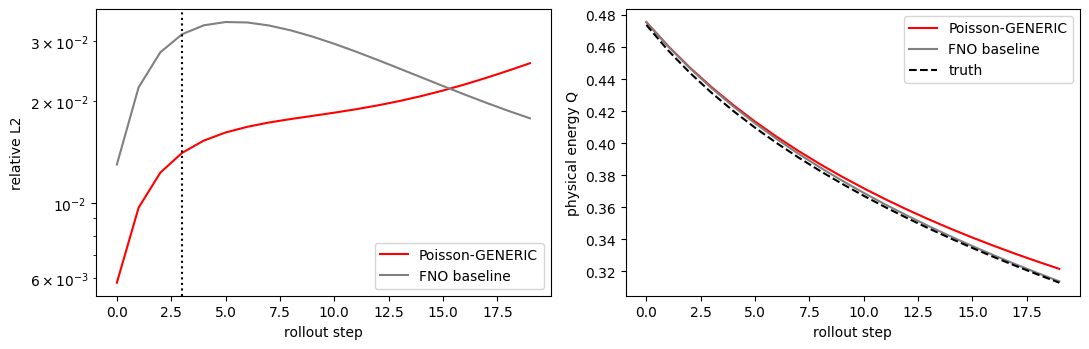

In [ ]:
cfg_pg = Cfg(dim=1, pde='heat', nx=64, n_traj=80, T=20, model='pg', backbone='fno', width=16, epochs=30, integrator='dg')
row_pg, model_pg = run_one(cfg_pg)
cfg_b = copy.deepcopy(cfg_pg); cfg_b.model = 'base'
row_b, model_b = run_one(cfg_b)

# rollout error and physical energy along a long rollout (past the training horizon)
data = get_data(cfg_pg); _, te = split_data(data); te = te.to(DEV); n = cfg_pg.T
with torch.no_grad():
    pred_pg, zs, _ = model_pg.rollout(te[:, 0], n, create_graph=False)
    pred_b, _, _ = model_b.rollout(te[:, 0], n, create_graph=False)
true = te[:, 1:1 + n]
err = lambda p: [rel_l2(p[:, t], true[:, t]).item() for t in range(n)]
Qf = lambda x: torch.stack([phys_energy(x[:, t], cfg_pg)[0].mean() for t in range(x.shape[1])]).cpu()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].semilogy(err(pred_pg), 'r', label='Poisson-GENERIC'); ax[0].semilogy(err(pred_b), 'gray', label='FNO baseline')
ax[0].axvline(cfg_pg.horizon - 1, ls=':', c='k'); ax[0].set(xlabel='rollout step', ylabel='relative L2'); ax[0].legend()
ax[1].plot(Qf(pred_pg), 'r', label='Poisson-GENERIC'); ax[1].plot(Qf(pred_b), 'gray', label='FNO baseline')
ax[1].plot(Qf(true), 'k--', label='truth'); ax[1].set(xlabel='rollout step', ylabel='physical energy Q'); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Experiment grid
`QUICK=True`: 1D only, 2 backbones, 1 seed (~10 min on a T4). `QUICK=False`: 1D+2D × 4 PDEs × 3 backbones × {baseline, PG, PG-physical} × seeds. Results are appended to `results.csv` so the cell can be re-run / resumed — **delete `results.csv` when the code changes**, otherwise old rows are kept. Edit `SEEDS`, `BACKBONES`, `PDES`, `DIMS` freely.

In [ ]:
QUICK = False
SEEDS     = [0] if QUICK else [0, 1, 2]
DIMS      = [1] if QUICK else [1, 2]
PDES      = ['heat', 'advection', 'burgers', 'wave']
BACKBONES = ['fno', 'transolver'] if QUICK else ['fno', 'transolver', 'cno']
VARIANTS = {                                   # name -> cfg overrides
    'base':    dict(model='base'),
    'pg':      dict(model='pg'),                                                        # learned E, Casimir S_phi, constant M
    'pgphys':  dict(model='pg', energy='physical', entropy='integral', m_type='state',   # fixed Q + phi(u) + e(s), S = int s, M(z),
                    integrator='split', train_integrator='split', n_sub=8, lie_poisson=True),   # L = alpha1 D + lambda(uD+Du) (scalar) / J (wave)
    'pgphysC': dict(model='pg', energy='physical', entropy='integral', m_type='state',   # same with a CONSTANT L (exact Jacobi for
                    integrator='split', train_integrator='split', n_sub=8, lie_poisson=False),  # any state; cannot represent Burgers)
}
MODELS = list(VARIANTS)

def cfg_for(dim, pde, backbone, variant, seed):
    if dim == 1:
        c = Cfg(dim=1, pde=pde, nx=64, n_traj=120, T=20, kmax=8, m_L=16, m_M=16, width=24, modes=12, layers=3,
                epochs=15 if QUICK else 60, batch=16, horizon=4, norm=False)
    else:
        c = Cfg(dim=2, pde=pde, nx=32, n_traj=80, T=15, kmax=6, m_L=10, m_M=10, width=24, modes=8, layers=3,
                epochs=10 if QUICK else 40, batch=8, horizon=3, norm=True)
    for k, v in VARIANTS[variant].items(): setattr(c, k, v)
    if variant == 'pg': c.width = 12                    # two functionals + encoder ~ one baseline budget
    if variant.startswith('pgphys'): c.m_M = c.nx // 3           # de-aliased band of the data: Burgers steepens beyond kmax (2D under-dissipated at m_M=kmax)
    c.backbone, c.seed = backbone, seed
    if not variant.startswith('pgphys'): c.integrator = c.train_integrator = 'euler'   # BUG FIX: this line previously
    #   matched 'pgphysC' too, so the constant-L ablation was trained/evaluated with explicit Euler instead of the split step   # consistent; DG evaluated separately in Sec. 10
    return c

import os
rows = pd.read_csv('results.csv').to_dict('records') if os.path.exists('results.csv') else []
done = {(r['dim'], r['pde'], r['backbone'], r['model'], r['seed']) for r in rows}
MODELS_STORE = {}
for dim, pde, bb, mt, sd in itertools.product(DIMS, PDES, BACKBONES, MODELS, SEEDS):
    if (dim, pde, bb, mt, sd) in done: continue
    row, mdl = run_one(cfg_for(dim, pde, bb, mt, sd)); row['model'] = mt
    rows.append(row); MODELS_STORE[(dim, pde, bb, mt, sd)] = mdl
    pd.DataFrame(rows).to_csv('results.csv', index=False)
df = pd.DataFrame(rows)
display(df.groupby(['dim', 'pde', 'backbone', 'model'])[['params', 'l2_1step', 'l2_rollout', 'l2_persist', 'rmech', 'Pi_model', 'Pi_star', 'Q_ratio_final', 'Qmax_over_bound', 'phi_min', 'rE', 'dE_rel', 'min_dS']].mean())

[1D heat      fno        base] params=44,593
  ep   0  loss 0.0876  (0s)
  ep  12  loss 0.0087  (2s)
  ep  24  loss 0.0017  (3s)
  ep  36  loss 0.0014  (5s)
  ep  48  loss 0.0006  (6s)
  ep  59  loss 0.0004  (8s)
    {'params': 44593, 'train_s': 7.8088, 'final_loss': 0.0004, 'l2_1step': 0.0005, 'l2_rollout': 0.0012, 'l2_final': 0.0016, 'rmech': 0.5833, 'Pi_star': 0.0312, 'Pi_model': 0.0311, 'Q_ratio_final': 1.0001, 'l2_persist': 0.1831}
[1D heat      fno        base] params=44,593
  ep   0  loss 0.2089  (0s)
  ep  12  loss 0.0032  (2s)
  ep  24  loss 0.0036  (3s)
  ep  36  loss 0.0016  (5s)
  ep  48  loss 0.0009  (6s)
  ep  59  loss 0.0004  (8s)
    {'params': 44593, 'train_s': 7.758, 'final_loss': 0.0004, 'l2_1step': 0.0006, 'l2_rollout': 0.0014, 'l2_final': 0.0018, 'rmech': 0.5671, 'Pi_star': 0.0315, 'Pi_model': 0.0315, 'Q_ratio_final': 1.0004, 'l2_persist': 0.1906}
[1D heat      fno        base] params=44,593
  ep   0  loss 0.3621  (0s)
  ep  12  loss 0.0055  (2s)
  ep  24  loss 0.0

params  l2_1step  l2_rollout  l2_persist  \
dim pde       backbone   model                                                 
1   advection cno        base      21025.0  0.002627    0.012357    0.862571   
                         pg        15463.0  0.004288    0.035461    0.862571   
                         pgphys    12822.0  0.000242    0.001330    0.862571   
                         pgphysC   12822.0  0.000021    0.000113    0.862571   
              fno        base      44593.0  0.000862    0.003778    0.862571   
...                                    ...       ...         ...         ...   
2   wave      fno        pgphysC  146494.0  0.044512    0.035150    1.025819   
              transolver base      33965.0  0.612448    0.843736    1.025819   
                         pg       112762.0  0.162420    0.759588    1.025819   
                         pgphys    68897.0  0.042154    0.034202    1.025819   
                         pgphysC   68897.0  0.042154    0.034202    1.025819   

                                         rmech      Pi_model       Pi_star  \
dim pde       backbone   model                                               
1   advection cno        base     3.617146e-04  1.403314e-04  1.681966e-08   
                         pg       7.600586e-03  1.818248e-03  1.681966e-08   
                         pgphys   8.811064e-07  3.515313e-07  1.681966e-08   
                         pgphysC  8.871727e-07  3.589320e-07  1.681966e-08   
              fno        base     3.833007e-05  3.430641e-05  1.681966e-08   
...                                        ...           ...           ...   
2   wave      fno        pgphysC  1.524499e-02  2.698466e-02  2.881258e-02   
              transolver base     2.005183e-01  1.651963e-01  2.881258e-02   
                         pg      -1.117780e-01 -1.296795e-01  2.881258e-02   
                         pgphys   1.441546e-02  2.551389e-02  2.881258e-02   
                         pgphysC  1.441546e-02  2.551389e-02  2.881258e-02   

                                  Q_ratio_final  Qmax_over_bound   phi_min  \
dim pde       backbone   model                                               
1   advection cno        base          0.998634              NaN       NaN   
                         pg            0.985121              NaN       NaN   
                         pgphys        0.999997         0.423554 -0.009222   
                         pgphysC       0.999997         0.429130 -0.000068   
              fno        base          0.999662              NaN       NaN   
...                                         ...              ...       ...   
2   wave      fno        pgphysC       1.021406         0.854471 -0.363376   
              transolver base          0.206754              NaN       NaN   
                         pg            4.456293              NaN       NaN   
                         pgphys        1.036717         0.848543 -0.362461   
                         pgphysC       1.036717         0.848543 -0.362461   

                                            rE        dE_rel        min_dS  
dim pde       backbone   model                                              
1   advection cno        base              NaN           NaN           NaN  
                         pg       1.303742e-08  1.611120e-01  1.620505e-02  
                         pgphys   2.958405e-05  7.562362e-08 -3.973643e-08  
                         pgphysC  1.822053e-06  7.748350e-08 -4.470348e-08  
              fno        base              NaN           NaN           NaN  
...                                        ...           ...           ...  
2   wave      fno        pgphysC  1.039661e-03  4.049890e-04  1.845364e-01  
              transolver base              NaN           NaN           NaN  
                         pg       4.039734e-09  1.061347e-01  3.026994e-02  
                         pgphys   1.025382e-03  4.068122e-04  1.734482e-01  
                         pgphysC  1.02538

### Plots: rollout accuracy per backbone, and the gauge-invariant dissipation test

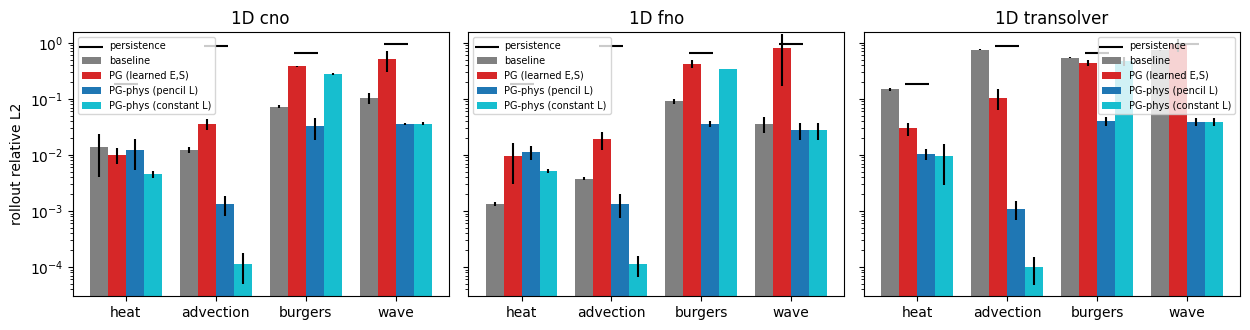

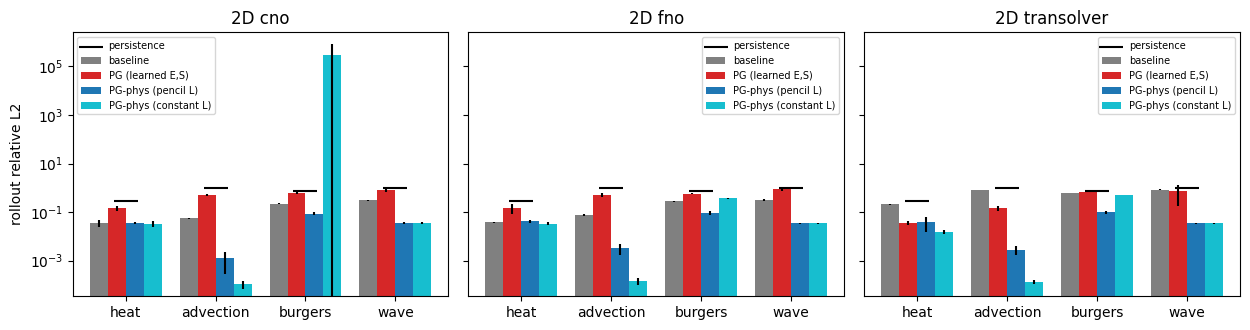

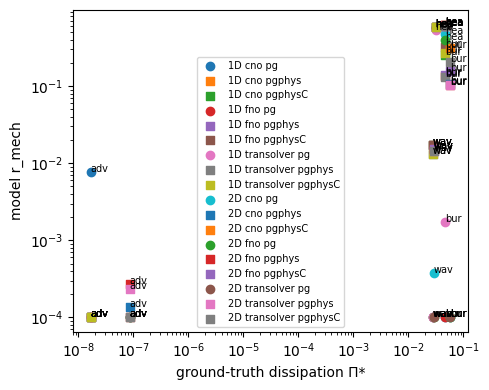

Pi_star                                \
pde                        advection   burgers      heat      wave   
dim backbone   model                                                 
1   cno        pg       1.681966e-08  0.046850  0.031182  0.027758   
               pgphys   1.681966e-08  0.046850  0.031182  0.027758   
               pgphysC  1.681966e-08  0.046850  0.031182  0.027758   
    fno        pg       1.681966e-08  0.046850  0.031182  0.027758   
               pgphys   1.681966e-08  0.046850  0.031182  0.027758   
               pgphysC  1.681966e-08  0.046850  0.031182  0.027758   
    transolver pg       1.681966e-08  0.046850  0.031182  0.027758   
               pgphys   1.681966e-08  0.046850  0.031182  0.027758   
               pgphysC  1.681966e-08  0.046850  0.031182  0.027758   
2   cno        pg       8.576547e-08  0.056647  0.046754  0.028813   
               pgphys   8.576547e-08  0.056647  0.046754  0.028813   
               pgphysC  8.576547e-08  0.056647  0.046754  0.028813   
    fno        pg       8.576547e-08  0.056647  0.046754  0.028813   
               pgphys   8.576547e-08  0.056647  0.046754  0.028813   
               pgphysC  8.576547e-08  0.056647  0.046754  0.028813   
    transolver pg       8.576547e-08  0.056647  0.046754  0.028813   
               pgphys   8.576547e-08  0.056647  0.046754  0.028813   
               pgphysC  8.576547e-08  0.056647  0.046754  0.028813   

                               rmech                                
pde                        advection   burgers      heat      wave  
dim backbone   model                                                
1   cno        pg       7.600586e-03 -0.022049  0.581287 -0.038974  
               pgphys   8.811064e-07  0.137020  0.582012  0.017270  
               pgphysC  8.871727e-07  0.251894  0.576999  0.017258  
    fno        pg      -5.363043e-04 -0.251363  0.573956 -0.169974  
               pgphys   1.905491e-06  0.138503  0.588225  0.017392  
               pgphysC  8.337409e-07  0.318275  0.579558  0.017415  
    transolver pg      -2.859919e-02  0.001715  0.531819 -0.240032  
               pgphys   3.427760e-05  0.132999  0.586916  0.013081  
               pgphysC  8.502990e-07  0.266731  0.587525  0.013081  
2   cno        pg      -1.154564e-01 -0.057406  0.475751  0.000381  
               pgphys   1.353868e-04  0.105094  0.625561  0.015247  
               pgphysC  1.735628e-06  0.313840  0.618427  0.015247  
    fno        pg      -1.182833e-01 -0.026982  0.391936 -0.056599  
               pgphys   2.731862e-04  0.103294  0.619006  0.015245  
               pgphysC  1.853760e-06  0.154914  0.597276  0.015245  
    transolver pg      -3.462340e-02 -0.066293  0.596004 -0.111778  
               pgphys   2.329110e-04  0.104617  0.602977  0.014415  
               pgphysC  1.866186e-06  0.208058  0.601900  0.014415

Pi_model  Pi_star        ratio
dim backbone   model   pde                                      
1   cno        pg      advection    0.0018   0.0000  108102.5402
                       burgers      0.0027   0.0468       0.0580
                       heat         0.0308   0.0312       0.9862
                       wave        -0.1061   0.0278      -3.8226
               pgphys  advection    0.0000   0.0000      20.9000
...                                    ...      ...          ...
2   transolver pgphys  wave         0.0255   0.0288       0.8855
               pgphysC advection    0.0000   0.0000      11.8203
                       burgers      0.0753   0.0566       1.3300
                       heat         0.0488   0.0468       1.0428
                       wave         0.0255   0.0288       0.8855

[72 rows x 3 columns]

In [ ]:
g = df.groupby(['dim', 'pde', 'backbone', 'model'])['l2_rollout'].agg(['mean', 'std']).reset_index()
for dim in sorted(df.dim.unique()):
    sub = g[g.dim == dim]; bbs = sorted(sub.backbone.unique())
    fig, axes = plt.subplots(1, len(bbs), figsize=(4.2 * len(bbs), 3.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, bb in zip(axes, bbs):
        s = sub[sub.backbone == bb]
        for j, mt in enumerate(MODELS):
            ss = s[s.model == mt].set_index('pde').reindex(PDES)
            ax.bar(np.arange(len(PDES)) + 0.2 * j, ss['mean'], 0.2, yerr=ss['std'].fillna(0), color=['gray', 'tab:red', 'tab:blue', 'tab:cyan'][j],
                   label={'base': 'baseline', 'pg': 'PG (learned E,S)', 'pgphys': 'PG-phys (pencil L)', 'pgphysC': 'PG-phys (constant L)'}[mt])
        pers = df[(df.dim == dim) & (df.backbone == bb)].groupby('pde')['l2_persist'].mean().reindex(PDES)
        ax.scatter(np.arange(len(PDES)) + 0.3, pers, marker='_', s=300, c='k', zorder=5, label='persistence')
        ax.set(title=f'{dim}D {bb}', xticks=np.arange(len(PDES)) + 0.3, xticklabels=PDES, yscale='log'); ax.legend(fontsize=7)
    axes[0].set_ylabel('rollout relative L2'); plt.tight_layout(); plt.show()

# r_mech (model) vs Pi* (truth): advection should sit at ~0, heat clearly positive, ordering ordinal
pg = df[df.model != 'base'].groupby(['dim', 'backbone', 'model', 'pde'])[['rmech', 'Pi_star']].mean().reset_index()
fig, ax = plt.subplots(figsize=(5, 4))
for (dim, bb, mt), s in pg.groupby(['dim', 'backbone', 'model']):
    ax.scatter(s.Pi_star.clip(lower=1e-8), s.rmech.clip(lower=1e-4), marker='o' if mt == 'pg' else 's', label=f'{dim}D {bb} {mt}')
    for _, r in s.iterrows(): ax.annotate(r.pde[:3], (max(r.Pi_star, 1e-8), max(r.rmech, 1e-4)), fontsize=7)
ax.set(xscale='log', yscale='log', xlabel='ground-truth dissipation Π*', ylabel='model r_mech'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
display(pg.pivot_table(index=['dim', 'backbone', 'model'], columns='pde', values=['rmech', 'Pi_star']))
# magnitude comparison: model's fractional dissipation of Q vs the truth's, same normalization
pm = df[df.model != 'base'].groupby(['dim', 'backbone', 'model', 'pde'])[['Pi_model', 'Pi_star']].mean()
pm['ratio'] = pm['Pi_model'] / pm['Pi_star'].clip(lower=1e-9)
display(pm.round(4))

## 10. Zero-shot super-resolution and the integrator study
Left: a model trained at `nx` evaluated unchanged at `2nx`, `4nx` on the same band-limited initial conditions re-integrated at the fine grid — accuracy **and** the structural residuals should be flat (FNO and Transolver only; CNO-lite is not resolution-invariant by design). Right: the same trained model rolled out with explicit Euler vs. the discrete-gradient step — `dE_rel` drops from `O(Δt²)` to the float32 floor (re-run §7 for the float64 version).

In [ ]:
def prolong(u, nx_new):
    """Band-limited (Fourier zero-padding) interpolation of (B, C, *grid) to a finer grid."""
    dim = u.dim() - 2; d = sdims(dim); nx = u.shape[-1]
    uf = torch.fft.fftn(u.double(), dim=d)
    uf = torch.fft.fftshift(uf, dim=d)
    pad = (nx_new - nx) // 2
    uf = F.pad(uf, [pad, pad] * dim)
    uf = torch.fft.ifftshift(uf, dim=d)
    return torch.fft.ifftn(uf, dim=d).real.to(u.dtype) * (nx_new / nx) ** dim

def gen_data_from_ic(cfg, u0):
    """Integrate given initial conditions (B, p, *grid) with the spectral solver at their own resolution."""
    prm = PDE_PARAMS[cfg.pde]; sp = Spectral(u0.shape[-1], cfg.dim, u0.device)
    n_sub = n_substeps(cfg, u0.shape[-1]); dt_sub = cfg.dt / n_sub
    f = lambda x: pde_rhs(cfg.pde, x, sp, prm); u = u0.double(); frames = [u]
    with torch.no_grad():
        for _ in range(cfg.T):
            for _ in range(n_sub): u = rk4(f, u, dt_sub)
            frames.append(u)
    return torch.stack(frames, 1).float()

def superres_eval(model, cfg, factors=(1, 2, 4)):
    """Zero-shot super-resolution: same band-limited ICs prolonged to finer grids, re-integrated there,
    the model (trained at cfg.nx) applied unchanged. Structural residuals travel with it."""
    data = get_data(cfg); _, te = split_data(data); u0 = te[:, 0].to(DEV)
    rows = []
    for fct in factors:
        nx = cfg.nx * fct
        fine = gen_data_from_ic(cfg, prolong(u0, nx) if fct > 1 else u0)
        r = evaluate(model, fine, cfg); r['nx'] = nx; rows.append(r)
    return pd.DataFrame(rows).set_index('nx')

In [ ]:
# CNO-lite is excluded: its 3-point convolution kernels are defined in grid units, so it is not resolution-invariant by design.
SR_KEYS = [k for k in MODELS_STORE if k[3] == 'pgphys' and k[2] != 'cno' and k[1] in ('heat', 'burgers', 'wave')][:3]
for key in SR_KEYS:
    dim, pde, bb, mt, sd = key; mdl = MODELS_STORE[key]; cfg = cfg_for(dim, pde, bb, mt, sd)
    print('super-resolution of', key)
    display(superres_eval(mdl, cfg, factors=(1, 2, 4)))
key = next(k for k in MODELS_STORE if k[3] == 'pgphys' and k[2] != 'cno')
dim, pde, bb, mt, sd = key; mdl = MODELS_STORE[key]; cfg = cfg_for(dim, pde, bb, mt, sd)
op_tables = {}
for key_ in [k for k in MODELS_STORE if k[3] == 'pgphys' and k[0] == 1 and k[1] in ('advection', 'wave')]:
    d_, p_, b_, m_, s_ = key_; tab = operator_diagnostic(MODELS_STORE[key_], cfg_for(d_, p_, b_, m_, s_))
    if tab is not None:
        op_tables[key_] = tab; print('learned reversible symbol vs exact:', key_); display(tab.T.round(3))

print('integrator study (same trained model):', key)
data = get_data(cfg); _, te = split_data(data); out = {}
for integ, iters in [('split', 0), ('dg', 3), ('dg', 6), ('dg', 12)]:   # split = the integrator pgphys was trained with
    c = copy.deepcopy(cfg); c.integrator = integ; c.dg_iters = max(iters, 1); mdl.cfg = c
    out[f'{integ}{iters if integ=="dg" else ""}'] = evaluate(mdl, te, c)
mdl.cfg = cfg
display(pd.DataFrame(out).T[['l2_rollout', 'rE', 'dE_rel', 'min_dS', 'Pi_model', 'Qmax_over_bound']])

super-resolution of (1, 'heat', 'fno', 'pgphys', 0)


,l2_1step,l2_rollout,l2_final,rmech,Pi_star,Pi_model,Q_ratio_final,phi_min,Qmax_over_E0,Qmax_over_bound,rE,dE_rel,min_dS
nx,,,,,,,,,,,,,
64,0.003582,0.008338,0.015025,0.589611,0.031155,0.030416,1.007742,-0.005805,0.122675,0.139301,0.003178,0.000014,0.006764
128,0.003575,0.008318,0.015000,0.589589,0.031155,0.030427,1.007635,-0.005805,0.122489,0.139097,0.003177,0.000014,0.006765
256,0.003576,0.008311,0.014986,0.589598,0.031155,0.030434,1.007563,-0.005809,0.122396,0.138995,0.003174,0.000014,0.006765


super-resolution of (1, 'heat', 'fno', 'pgphys', 1)


,l2_1step,l2_rollout,l2_final,rmech,Pi_star,Pi_model,Q_ratio_final,phi_min,Qmax_over_E0,Qmax_over_bound,rE,dE_rel,min_dS
nx,,,,,,,,,,,,,
64,0.005994,0.014650,0.029897,0.574102,0.03152,0.028842,1.028320,-0.007239,0.159745,0.176325,0.003823,0.000024,0.004962
128,0.005993,0.014639,0.029861,0.574086,0.03152,0.028847,1.028269,-0.007239,0.159661,0.176236,0.003823,0.000024,0.004964
256,0.005994,0.014633,0.029842,0.574072,0.03152,0.028850,1.028241,-0.007239,0.159619,0.176192,0.003821,0.000024,0.004965


super-resolution of (1, 'heat', 'fno', 'pgphys', 2)


...

k,1,2,3,4,5,6,7,8
learned,0.1,0.101,0.102,0.101,0.101,0.101,0.101,0.101
exact,0.1,0.100,0.100,0.100,0.100,0.100,0.100,0.100


learned reversible symbol vs exact: (1, 'wave', 'cno', 'pgphys', 2)


k,1,2,3,4,5,6,7,8
learned,0.1,0.1,0.1,0.101,0.101,0.101,0.1,0.1
exact,0.1,0.1,0.1,0.100,0.100,0.100,0.1,0.1


integrator study (same trained model): (1, 'heat', 'fno', 'pgphys', 0)


,l2_rollout,rE,dE_rel,min_dS,Pi_model,Qmax_over_bound
split,0.008338,0.003178,1.385659e-05,0.006764,0.030416,0.139301
dg3,0.008827,0.000062,3.477615e-06,0.006754,0.030366,0.139309
dg6,0.008691,0.000004,2.215538e-07,0.006754,0.030370,0.139307
dg12,0.008693,0.000002,3.445557e-08,0.006754,0.030371,0.139306


### Re-evaluate already-trained models (no retraining) after a metrics change

In [ ]:
# Use when evaluate() changed but MODELS_STORE still holds the trained models of this session.
if MODELS_STORE:
    rows2 = []
    for (dim, pde, bb, mt, sd), mdl in MODELS_STORE.items():
        c = cfg_for(dim, pde, bb, mt, sd); data = get_data(c); _, te = split_data(data)
        row = dict(dim=dim, pde=pde, backbone=bb, model=mt, seed=sd, params=count_params(mdl)); row.update(evaluate(mdl, te, c))
        te_d = te.to(DEV); n = min(c.n_roll, c.T)
        row['l2_persist'] = float(np.mean([rel_l2(te_d[:, 0], te_d[:, 1 + t]).item() for t in range(n)])); rows2.append(row)
    df = pd.DataFrame(rows2); df.to_csv('results.csv', index=False)
    display(df.groupby(['dim', 'pde', 'backbone', 'model'])[['l2_rollout', 'rmech', 'Pi_model', 'Pi_star', 'Q_ratio_final', 'Qmax_over_bound', 'phi_min']].mean())

l2_rollout         rmech      Pi_model  \
dim pde       backbone   model                                             
1   advection cno        base       0.012357  3.617146e-04  1.403314e-04   
                         pg         0.035461  7.600587e-03  1.818247e-03   
                         pgphys     0.001330  8.811064e-07  3.515313e-07   
                         pgphysC    0.000113  8.871727e-07  3.589320e-07   
              fno        base       0.003778  3.833007e-05  3.430641e-05   
...                                      ...           ...           ...   
2   wave      fno        pgphysC    0.035150  1.524499e-02  2.698466e-02   
              transolver base       0.843736  2.005183e-01  1.651963e-01   
                         pg         0.759588 -1.117780e-01 -1.296795e-01   
                         pgphys     0.034202  1.441546e-02  2.551389e-02   
                         pgphysC    0.034202  1.441546e-02  2.551389e-02   

                                       Pi_star  Q_ratio_final  \
dim pde       backbone   model                                  
1   advection cno        base     1.681966e-08       0.998634   
                         pg       1.681966e-08       0.985121   
                         pgphys   1.681966e-08       0.999997   
                         pgphysC  1.681966e-08       0.999997   
              fno        base     1.681966e-08       0.999662   
...                                        ...            ...   
2   wave      fno        pgphysC  2.881258e-02       1.021406   
              transolver base     2.881258e-02       0.206754   
                         pg       2.881258e-02       4.456293   
                         pgphys   2.881258e-02       1.036717   
                         pgphysC  2.881258e-02       1.036717   

                                  Qmax_over_bound   phi_min  
dim pde       backbone   model                               
1   advection cno        base                 NaN       NaN  
                         pg                   NaN       NaN  
                         pgphys          0.423554 -0.009222  
                         pgphysC         0.429130 -0.000068  
              fno        base                 NaN       NaN  
...                                           ...       ...  
2   wave      fno        pgphysC         0.854471 -0.363376  
              transolver base                 NaN       NaN  
                         pg                   NaN       NaN  
                         pgphys          0.848543 -0.362461  
                         pgphysC         0.848543 -0.362461  

[96 rows x 7 columns]

## 11. Review bundle
Writes one long-format CSV (`section, key, value`) with the verification tables, the representability check, the full results grid, the super-resolution table, and the integrator study.

In [ ]:
# Reproducibility check for the constant-L (pgphysC) wave divergence: train BOTH physical variants on the same
# (1, wave, fno, seed 0) cell twice each. The two variants share the wave code path (lie_poisson is off for the wave),
# so their results should be identical up to GPU nondeterminism; the columns below say whether the divergence reproduces.
chk_rows = []
for variant in ['pgphys', 'pgphysC']:
    for rep_ in range(2):
        c = cfg_for(1, 'wave', 'fno', variant, 0)
        row, _ = run_one(c, verbose=False); row['variant'] = variant; row['rep'] = rep_; chk_rows.append(row)
chk = pd.DataFrame(chk_rows)[['variant', 'rep', 'l2_rollout', 'Q_ratio_final', 'Qmax_over_bound', 'dE_rel', 'min_dS']]
display(chk)
CHK_PARTS = [dict(section='wave_check', key=f"{r['variant']}|rep{r['rep']}|{col}", value=r[col])
             for _, r in chk.iterrows() for col in ['l2_rollout', 'Q_ratio_final', 'Qmax_over_bound', 'dE_rel']]

,variant,rep,l2_rollout,Q_ratio_final,Qmax_over_bound,dE_rel,min_dS
0,pgphys,0,0.023422,1.059185,0.877819,0.000120,0.032803
1,pgphys,1,0.022559,1.053700,0.878946,0.000122,0.031369
2,pgphysC,0,0.024623,1.060470,0.879088,0.000121,0.033259
3,pgphysC,1,0.025793,1.062951,0.880391,0.000122,0.034861


In [ ]:
parts = []
for name, tab in tables.items():
    parts += [dict(section='verification', key=f'{name} | {k}', value=v) for k, v in tab.items()]
parts += [dict(section='representability', key=k, value=v) for k, v in rep.items()]
for _, r in df.iterrows():
    r = dict(r); r['train_s_per_epoch'] = r.get('train_s', float('nan')) / cfg_for(r['dim'], r['pde'], r['backbone'], r['model'], r['seed']).epochs
    for col in r:
        if col in ('dim', 'pde', 'backbone', 'model', 'seed'): continue
        parts.append(dict(section='grid', key=f"{r['dim']}D|{r['pde']}|{r['backbone']}|{r['model']}|seed{r['seed']}|{col}", value=r[col]))
try:
    for key_ in SR_KEYS:
        d_, p_, b_, m_, s_ = key_; sr = superres_eval(MODELS_STORE[key_], cfg_for(d_, p_, b_, m_, s_), factors=(1, 2, 4))
        for nx_, r in sr.iterrows():
            for col in sr.columns: parts.append(dict(section='superres', key=f'{d_}D|{p_}|{b_}|{m_}|nx{nx_}|{col}', value=r[col]))
    for integ, r in pd.DataFrame(out).T.iterrows():
        for col in r.index: parts.append(dict(section='integrator', key=f'{integ}|{col}', value=r[col]))
    lp = lie_poisson_jacobi_vs_resolution()
    for nx_, r in lp.iterrows(): parts.append(dict(section='lp_jacobi', key=f'nx{nx_}|band{int(r["band"])}', value=r['jacobi']))
    for key_, tab in op_tables.items():
        for k_, r in tab.iterrows():
            parts.append(dict(section='operator', key=f'{key_[0]}D|{key_[1]}|{key_[2]}|k{k_}|learned', value=r['learned']))
            parts.append(dict(section='operator', key=f'{key_[0]}D|{key_[1]}|{key_[2]}|k{k_}|exact', value=r['exact']))
except Exception as e:
    print('partial bundle:', e)
parts += globals().get('CHK_PARTS', [])
review = pd.DataFrame(parts); review.to_csv('poisson_generic_review.csv', index=False)
print(len(review), 'rows written to poisson_generic_review.csv')
try:
    from google.colab import files; files.download('poisson_generic_review.csv')
except Exception: pass

## Notes for the write-up
* **What is exact.** Skewness, PSD, both degeneracies, Jacobi (constant `L`), and — under the DG step — the discrete first and second laws. §7 measures all of them, including the Jacobi residual of the old projected `L` on the same test functionals.
* **What is not.** Whether `E_θ, S_φ` match the physical energy/entropy (gauge); whether the learned flow matches the PDE (accuracy). `r_mech` vs `Π*` is the gauge-invariant test.
* **Known knobs.** `norm` (InstanceNorm) per the first paper's diagnosis; `K_mode`; `s_init`; `op_init` (too small and PG starts in the identity basin); `train_integrator='dg'` for exact-in-training at `dg_iters×` cost.